In [13]:
import numpy as np
import pandas as pd
import pickle
import time
import os
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import copy
import math
import torch.nn.utils.prune as prune
from sklearn.metrics import accuracy_score, classification_report
import torch.nn.functional as F
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchao.quantization import  Int8WeightOnlyConfig,IntxWeightOnlyConfig
from torchao.quantization import Float8WeightOnlyConfig, quantize_
#from torchao.prototype.mx_formats.inference_workflow import NVFP4WeightOnlyConfig
import re
from si_prefix import si_format


In [14]:
########## Classifier definitions ############

# Define Positional Encoding and Transformer Classifier
# It is important that they look the same as their counterparts in the main program
# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1)]

# Type of Transformer classifier
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        d_model: int,
        nhead: int ,
        num_layers: int,
        dim_feedforward: int,
        dropout: float ,
        max_len: int ,
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x)
        center_idx = x.size(1) // 2
        x = self.norm(x[:, center_idx, :])
        return self.classifier(x)


In [15]:
#################  Function definitions  #################

#Load data
def loadData(path):  # load IQ data from CSV files in given folder path
    inputFiles = glob.glob(os.path.join(path, "*.csv"))
    if not inputFiles:
        raise FileNotFoundError(f"No CSV files found in: {path}")   
    
    dataFrame = pd.DataFrame()
    
    for file in inputFiles:
        df = pd.read_csv(file)
        dataFrame = pd.concat([dataFrame, df], ignore_index=True)
    label = dataFrame["label_index"].values
    return dataFrame, label

# Sliding windows
def make_windows(X: np.ndarray, y: np.ndarray, window: int, hop: int = 1):
    """Build sliding windows and use the center-symbol label as window target."""
    if len(X) < window:
        raise ValueError(f"Need at least {window} symbols, got {len(X)}")

    Xw, yw = [], []
    center = window // 2
    for start in range(0, len(X) - window + 1, hop):
    
        end = start + window
        Xw.append(X[start:end])
        yw.append(y[start + center])

    return np.stack(Xw).astype(np.float32), np.array(yw, dtype=np.int64)


def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params


# def count_parameters2(model):
#     compModel = torch.compile(model)
#     total_params = sum(p.numel() for p in compModel.parameters())
#     trainable_params = sum(p.numel() for p in compModel.parameters() if p.requires_grad)
#     return total_params, trainable_params

def get_model_size_mb(path):
    size_mb = os.path.getsize(path) / (1024 ** 2)
    return size_mb

###### Quantization function definitions #####

def quantize_model(model, config):
    quantized_model = copy.deepcopy(model)
    quantize_(quantized_model, config)
    return quantized_model



In [16]:
#### Pruning function definitions ##### 
def compute_gradient_importance_scores(
    model,
    calibration_loader,
    device,
    loss_fn=None,
    target_names=None,
):
    """
    Compute gradient-based importance scores for structured pruning.

    Returns a dictionary that maps parameter names to tensors with the same shape as
    the corresponding parameter. The score used here is |w * grad| averaged
    over the calibration batches.
    """
    if loss_fn is None: # if no other loss function is specified, use cross entropy loss function
        loss_fn = nn.CrossEntropyLoss() 

    model.eval() # turn on evaluation mode

    importance_scores = {}  # initizalize dictionary for importance scores
    for name, param in model.named_parameters(): # loop through parameters
        if param.requires_grad: # "if trainable parameters"
            # create entry in the dictionary with an initial tensor of zeroes
            importance_scores[name] = torch.zeros_like(param, device="cpu", dtype=torch.float32)

    num_batches = 0

    for xb, yb in calibration_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        model.zero_grad(set_to_none=True) # sets grads to none
        outputs = model(xb) # calculate model's logits (unnormalized class scores)
        loss = loss_fn(outputs, yb) # loss function based on prediction logits and true labels
        loss.backward() # triggers backpropagation. Computes gradient of the loss and stores it in .grad

        with torch.no_grad():
            for name, param in model.named_parameters():
                # skip to next for loop run if parameter is not trainable or if it has no gradient value
                if not param.requires_grad or param.grad is None:
                    continue
                # skip to next for loop run if parameter name is not part of target parameter names
                if target_names is not None and name not in target_names:
                    continue
                # calculate importance score by multiplying parameter with loss gradient of parameter
                score = (param.detach() * param.grad.detach()).abs().to("cpu", dtype=torch.float32)
                importance_scores[name] += score

        num_batches += 1

    if num_batches == 0:
        raise ValueError("calibration_loader produced no batches")

    # divide importance score tensor entries in dictionary by the number of batches
    for name in importance_scores:
        importance_scores[name] /= num_batches

    
    return importance_scores


def structured_prune_ffn(model, amount, importance_scores):
    layer_count = 0
    for module in model.modules(): # go through the modules in the model
        if isinstance(module, nn.TransformerEncoderLayer): # if the current module is an instance of the TransformerEncoder class
            # Prune linear1 (expand layer)
            key = f"encoder.layers.{layer_count}.linear1.weight"
            prune.ln_structured( # prune the linear layer "linear1"
                module.linear1, # the tensor to prune is the linear1 layer
                name="weight", # the parameter to prune based on
                amount=amount, # pruning ratio
                n=2, # the 2-norm is used.
                dim=0,  # prune neurons (rows)
                importance_scores=importance_scores[key].to(module.linear1.weight.device)
            )

            # Prune linear2 (project back)
            key = f"encoder.layers.{layer_count}.linear2.weight"
            prune.ln_structured( # prune the linear layer "linear2"
                module.linear2, # the tensor to prune is the linear2 layer
                name="weight", # the parameter to prune based on
                amount=amount, # pruning ratio
                n=2, # the 2-norm is used
                dim=1,  # match dimension
                importance_scores=importance_scores[key].to(module.linear2.weight.device)
            )
            layer_count += 1

    return model


def rebuild_model_pruned(pruned_model, threshold=0.0):
    """
    Rebuild a pruned TransformerClassifier by shrinking FFN (feed-forward network) widths inside each
    TransformerEncoderLayer.

    This keeps d_model and attention dimensions unchanged (safe for MHA (multi-head attention)), and
    compacts only linear1/linear2 in each encoder layer.

    threshold: consider absolute weights <= threshold as pruned.
    Returns a new model with smaller FFN sub-layers.
    """
    #new_model = copy.deepcopy(pruned_model)
    new_model = pruned_model # simply a reference variable to pruned model
    kept_dims = []

    # raise an error if the given model does not have encoder layers
    if not hasattr(new_model, "encoder") or not hasattr(new_model.encoder, "layers"):
        raise ValueError("Expected model.encoder.layers for TransformerClassifier-like model")

    # loop through all the encoder layers
    for layer_idx, layer in enumerate(new_model.encoder.layers):
        linear1 = layer.linear1  # linear1 layer of current encoder layer
        linear2 = layer.linear2  # linear2 layer of current encoder layer

        # raise error if linear1 or linear2 are not part of this encoder layer
        if not isinstance(linear1, nn.Linear) or not isinstance(linear2, nn.Linear):
            raise ValueError(f"Encoder layer {layer_idx} does not have linear1/linear2 as nn.Linear")

       
        # tensor of booleans checking if weight values are greater than threshold (usually threshold = 0).
        # if any of these give "true", the method ".any()" turns the output into a single boolean saying "true".
        l1_row_active = (linear1.weight.data.abs() > threshold).any(dim=1)
        # if there is a bias value:
        # boolean expression whether bias is greater than threshold is bitwise OR'ed onto l1_row_active
        if linear1.bias is not None: 
            l1_row_active |= (linear1.bias.data.abs() > threshold)

        # same boolean expression principle as for l1_row_active, but for l2 columns (dim=0) this time
        l2_col_active = (linear2.weight.data.abs() > threshold).any(dim=0)
        
        # only keep FFN hidden units that are active in both projections by using bitwise AND.
        keep_mask = l1_row_active & l2_col_active  

        # Guarantee at least one hidden unit so the layer still works:
        # if there is no "true" at all in keep_mask,
        # locate index of the most important weight and set that index true in keep_mask
        if not keep_mask.any():
            keep_idx = torch.argmax(linear1.weight.data.abs().sum(dim=1)).item()
            keep_mask[keep_idx] = True

        # torch.where gets the indices where keepmask is true
        keep_indices = torch.where(keep_mask)[0]
        # the kept dimension of the layer is the number of elements in keep_indices
        kept_dim = int(keep_indices.numel()) 
        kept_dims.append(kept_dim)

        device = linear1.weight.device # device same as before
        dtype = linear1.weight.dtype # data type same as before

        # creating new linear layers to use for linear1 and linear2 with the reduced dimension kept_dim 
        new_linear1 = nn.Linear(
            linear1.in_features,
            kept_dim,
            bias=linear1.bias is not None,
            device=device,
            dtype=dtype,
        )
        new_linear2 = nn.Linear(
            kept_dim,
            linear2.out_features,
            bias=linear2.bias is not None,
            device=device,
            dtype=dtype,
        )
        # 
        with torch.no_grad(): # turns off gradient calculation
            # copy weights and biases from old linear1 according to the indices that we want to keep
            new_linear1.weight.copy_(linear1.weight.data[keep_indices, :])
            if linear1.bias is not None:
                new_linear1.bias.copy_(linear1.bias.data[keep_indices])
            
            # copy weights from old linear2 according to the indices that we want to keep. Copy all biases
            new_linear2.weight.copy_(linear2.weight.data[:, keep_indices])
            if linear2.bias is not None:
                new_linear2.bias.copy_(linear2.bias.data)

        layer.linear1 = new_linear1 # reassign linear1 layer of current encoder layer to the pruned version
        layer.linear2 = new_linear2 # reassign linear2 layer of current encoder layer to the pruned version

    print(f"Rebuilt Transformer FFN dims per encoder layer: {kept_dims}")
    return new_model



In [17]:
##### Knowledge Distilation function definitions #####
def kd_loss_fn(student_logits, teacher_logits, labels, temperature=4.0, alpha=0.7):
    hard_loss = F.cross_entropy(student_logits, labels)

    soft_loss = F.kl_div(
        F.log_softmax(student_logits / temperature, dim=1),
        F.softmax(teacher_logits / temperature, dim=1),
        reduction="batchmean",
    ) * (temperature ** 2)

    return alpha * soft_loss + (1.0 - alpha) * hard_loss

def evaluate_loss_acc(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * yb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += yb.size(0)

    return total_loss / total_count, total_correct / total_count


# KD Definition
def knowledgeDistilation(teacherModel,test_loader,train_loader, val_loader, device, lossTitle = "KD - Student Train and Validation loss", accTitle = "KD - Student Train and Validation accuracy", num_epochs = 100, learning_rate = 1e-3, weight_decay = 1e-4, student_config=None, num_classes = 16 ):
    
    if student_config is None:
        student_config = {
        "num_layers": 2,  # = 1
        "d_model": 8,  # = 1
        "nhead": 4, # = 1
        "dim_feedforward": 2,  # = 1
    }
    
    student = TransformerClassifier(
    input_dim=2,
    num_classes=num_classes,
    d_model=student_config["d_model"],
    nhead=student_config["nhead"],
    num_layers=student_config["num_layers"],
    dim_feedforward=student_config["dim_feedforward"],
    dropout=0.3,
    max_len=4096,
    ).to(device)
    
    temperature = 2
    alpha = 1
    
    # --------------------------------------------------
    # Teacher evaluation
    # --------------------------------------------------
    teacher_test_loss, teacher_test_acc = evaluate_loss_acc(teacherModel, test_loader, device)
    print(f"\nTeacher test loss: {teacher_test_loss:.4f} | Teacher test acc: {teacher_test_acc:.4f}")
    print("###Student Training###")
    # --------------------------------------------------
    # KD training
    # --------------------------------------------------
    optimizer = torch.optim.AdamW(
        student.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }
    no_new_learning_counter = 0
    no_new_learning_threshold = 3
    lowest_loss = float("inf")
    for epoch in range(1, num_epochs + 1):
        student.train()

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            with torch.no_grad():
                teacher_logits = teacherModel(xb)

            student_logits = student(xb)

            loss = kd_loss_fn(
                student_logits,
                teacher_logits,
                yb,
                temperature=temperature,
                alpha=alpha,
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * yb.size(0)
            total_correct += (student_logits.argmax(dim=1) == yb).sum().item()
            total_count += yb.size(0)
        epoch_loss = total_loss / total_count
        if epoch_loss < lowest_loss:
            lowest_loss = epoch_loss
            no_new_learning_counter = 0
        else:
            no_new_learning_counter += 1
        if no_new_learning_counter >= no_new_learning_threshold:
            print(f"Early stopping at epoch {epoch} due to no improvement in loss for {no_new_learning_threshold} consecutive epochs.")
            break
    
        

    train_loss = total_loss / total_count
    train_acc = total_correct / total_count

    val_loss, val_acc = evaluate_loss_acc(student, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
    f"Epoch {epoch:03d}/{num_epochs} | "
    f"Train loss={train_loss:.4f} Train Accuracy={train_acc:.4f} | "
    f"Validation loss={val_loss:.4f} Validation Accuracy={val_acc:.4f}"
    )
    return student



In [18]:
###### Model evaluation definition #####

def totalEvaulation(model, test_loader, device,pipeLine = "Pipeline structure - Placeholder", CM_title = "Model Performance Evaluation - Placeholder",CM_SaveName = "CM Save Name Placeholder", fileName = "model_metrics_placeholder", show_cm=True):
    model.eval()
    num_classes = 16
    #path = f"{model.name()}.pth"
    torch.save(model.state_dict(), "modelSnapshot.pth")
    path = "modelSnapshot.pth"
    preds = []
    targets = []
    file_sizes = []
    accuracies = []
    total_times = []
    avg_times_per_sample = []
    avg_times_per_batch = []
    parameter_counts = []
    classification_reports = []
    torch.save(model.state_dict(), path)
    dataType = model.parameters().__next__().dtype
    bit_width = re.findall(r'[0-9]+', str(dataType))[0]
    
    
    
    intraDataFrame = pd.DataFrame({
    "Accuracy":[],
    "Precision" : [],
    "F1-score":[],
    "Total Inference time": [],
    "Batch Inference time":[],
    "Est. Sample Inference time": [],
    "Total parameters":[],
    "Memory footprint":[],
    "Data type":[],
    "Bit width":[]
    })
    

    n_samples = 0 # variable to hold how many samples through all batches
    batch_inference_times = []
    with torch.no_grad():
        for x_batch, y_batch, in test_loader:
            x_batch = x_batch.to(device)
            if device.type == "cuda": # synchronize cuda before measuring the time
                torch.cuda.synchronize()
            start_time = time.perf_counter()  # start time to measure inference (batch?)
            #outputs = prune_increment_model(x_batch)
            outputs = model(x_batch)
            predicted = torch.argmax(outputs, dim=1).cpu().numpy()
            if device.type == "cuda": # synchronize cuda before measuring the time
                torch.cuda.synchronize()
            end_time = time.perf_counter()  # end time to measure inference (batch?)
            preds.extend(predicted)
            targets.extend(y_batch.cpu())

            n_samples += x_batch.size(0)
            batch_inference_time = end_time - start_time
            batch_inference_times.append(batch_inference_time)
    
    report_dict = classification_report(targets, preds, output_dict=True, zero_division=0)
    cm = confusion_matrix(targets, preds)

    total_time = np.sum(batch_inference_times)
    avg_time_per_sample = total_time/n_samples
    avg_time_per_batch = np.mean(batch_inference_times)

    total_parameters, trainable_parameters = count_parameters(model)
    accuracy = accuracy_score(targets,preds) * 100
    size_mb = os.path.getsize(path) / (1024 ** 2)
    accuracies.append(accuracy) #calculate current accuracy
    total_times.append(total_time)
    avg_times_per_sample.append(avg_time_per_sample)
    avg_times_per_batch.append(avg_time_per_batch)
    parameter_counts.append(total_parameters)
    classification_reports.append(report_dict)

    if show_cm:
        fig, ax = plt.subplots(figsize=(10, 10))
        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=np.arange(num_classes),
        ).plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            xticks_rotation=0,
        )

        ax.set_title(f"{CM_title}")
        plt.tight_layout()
        plt.savefig(f"{CM_SaveName}.png", dpi=1200, bbox_inches="tight")
        plt.show()



    Performance_metrics_line = pd.DataFrame({
    
    "Accuracy":[accuracy],
    "F1-score":[report_dict["macro avg"]["f1-score"]*100],
    "Precision":[report_dict["macro avg"]["precision"]*100],
    "Total Inference time": [total_times[-1]],
    "Batch Inference time":[avg_times_per_batch[-1]],
    "Est. Sample Inference time": [avg_times_per_sample[-1]],
    "Total parameters":[total_parameters],
    "Memory footprint":[size_mb],
    "Data type":[dataType],
    "Bit width":[bit_width]
    })
    Performance_metrics_dataframe = pd.concat([intraDataFrame,Performance_metrics_line])
    
    savedData = pickle.dump(Performance_metrics_dataframe, open(f"{fileName}.pkl", "wb"))
    return Performance_metrics_dataframe


### Pruning ratio experiment definition #####
def pruning_ratio_experiment(
    base_model,
    test_loader,
    device,
    pruning_ratios,
    importances,
    output_csv="pruning_ratio_metrics.csv"
):
    results = []

    for ratio in pruning_ratios:
        print(f"\n==============================")
        print(f"Pruning ratio: {ratio}")
        print(f"==============================")

        model_copy = copy.deepcopy(base_model)

        pruned_model = structured_prune_ffn(model_copy, amount=ratio, importance_scores=importances)
        rebuilt_model = rebuild_model_pruned(pruned_model, threshold=0.0)

        metrics_df = totalEvaulation(
            rebuilt_model,
            test_loader,
            device,
            CM_SaveName=f"pruned_cm_ratio_{ratio}",
            CM_title=f"Pruned Model Performance - Ratio {ratio}",
            fileName=f"pruned_model_metrics_ratio_{ratio}",
            show_cm=False
        )

        metrics_df["Pruning Ratio"] = ratio
        results.append(metrics_df)

    pruning_results_df = pd.concat(results, ignore_index=True)
    pruning_results_df.to_csv(output_csv, index=False)

    print("\nSaved pruning ratio metrics to:", output_csv)

    return pruning_results_df

### Quantization type experiment definition #####
def quantization_type_experiment(
    base_model,
    test_loader,
    device,
    config_types,
    output_csv="quantization_type_metrics.csv"
):
    results = []

    for config_name, config in config_types.items():

        print("\n==============================")
        print(f"Quantization type: {config_name}")
        print("==============================")

        model_copy = copy.deepcopy(base_model)

        quantize_(model_copy, config)
        metrics_df = totalEvaulation(
            model_copy,
            test_loader,
            device,
            CM_SaveName=f"quantized_cm_{config_name}",
            CM_title=f"Quantized Model Performance - {config_name}",
            fileName=f"quantized_model_metrics_{config_name}",
            show_cm=False,
        )
        torch.save(model_copy, f"quantized_model_{config_name}.pth")
        print(f"Saved quantized model snapshot for {config_name}.")

        metrics_df["Quantization Type"] = config_name

        results.append(metrics_df)

    quantization_results_df = pd.concat(results, ignore_index=True)

    quantization_results_df.to_csv(output_csv, index=False)
    
#     original_metrics = totalEvaulation(
#     originalModel,
#     test_loader,
#     device,
#     CM_SaveName="original_model_cm",
#     CM_title="Original Model Performance",
#     fileName="original_model_metrics",
#     show_cm=False
# )

    original_metrics["Quantization Type"] = "float32 (Original)"
    original_metrics["Data type"] = "float32 (Original)"
    original_metrics["Bit width"] = 32

    quantization_results_df = pd.concat(
    [original_metrics, quantization_results_df],
    ignore_index=True
)

    print("\nSaved quantization metrics to:", output_csv)
    torch.save(base_model, "original_model_snapshot.pth")
    
    return quantization_results_df


## Model loader and Data loader part

In [19]:
## Value definitions
#################################### Main code ########################################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Model part for the Lenovo laptop
#model_path = Path(r"C:\Users\jonas\Documents\GitHub\6G_inFactory\3. Finale Pipeline Testing\model_16qam_rician_channel_snr_5_epoch_11.pth")
model_path = Path(r"C:\Users\mikep\Documents\GitHub\6G_inFactory\4. Absolutely final code\Quantize-Prune\model_16qam_rician_channel_snr_5_epoch_11.pth")

#Model path for shark gaming laptop
#model_path = Path(r"C:\GitHub\6G_inFactory\3. Finale Pipeline Testing\model_16qam_rician_channel_snr_5_epoch_11.pth")
modelLoaded = torch.load(model_path, map_location=device, weights_only=False)
originalModel = copy.deepcopy(modelLoaded) 
modelForQuantization = copy.deepcopy(modelLoaded)
modelForPruning = copy.deepcopy(modelLoaded)
modelForPipeline = copy.deepcopy(modelLoaded)
modelForKDfirst = copy.deepcopy(modelLoaded)
modelForKDlast = copy.deepcopy(modelLoaded)

### Experiment parameters and data loading ###
seq_len = 128
stride = 8
batch_size = 256

#CSV Path for the Lenovo laptop
#csv_path = Path(r"C:\Users\jonas\Documents\GitHub\6G_inFactory\3. Finale Pipeline Testing\16qam_noisy_with_labels_rician_fading_k_2.16_snr_5_evaluation_dataset3.csv")
csv_path = Path(r"C:\Users\mikep\Documents\GitHub\6G_inFactory\4. Absolutely final code\Quantize-Prune\16qam_noisy_with_labels_rician_fading_k_2.16_snr_5_evaluation_dataset3.csv")

#CSV Path for the Shark gaming laptop
#csv_path = Path(r"C:\GitHub\6G_inFactory\3. Finale Pipeline Testing\16qam_noisy_with_labels_rician_fading_k_2.16_snr_5_evaluation_dataset3.csv")

# The correct loading of data

# Load synthetic QAM symbol-level data

df = pd.read_csv(csv_path)

required_cols = ["noisy_I", "noisy_Q", "clean_I", "clean_Q", "label_index"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in {csv_path}: {missing}")

# Labels
y_symbol = df["label_index"].to_numpy(dtype=np.int64)

# Clean input for training
#X_clean = df[["clean_I", "clean_Q"]].to_numpy(dtype=np.float32)

# Noisy input for validation/testing
X_noisy = df[["noisy_I", "noisy_Q"]].to_numpy(dtype=np.float32)

num_classes = int(y_symbol.max()) + 1
print(f"Loaded {len(df)} symbols | classes: {num_classes}")


# the correct splitting of data

# Split on symbol stream first to avoid overlap leakage across splits
n_total = len(y_symbol)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)

# Train on noisy
X_train_sym = X_noisy[0:n_train]
y_train_sym = y_symbol[0:n_train]

# Validate on noisy
X_val_sym = X_noisy[n_train : n_train + n_val]
y_val_sym = y_symbol[n_train : n_train + n_val]

# Test on noisy
X_test_sym = X_noisy[n_train + n_val:]
y_test_sym = y_symbol[n_train + n_val:]

X_train, y_train = make_windows(X_train_sym, y_train_sym, seq_len, stride)
X_val, y_val = make_windows(X_val_sym, y_val_sym, seq_len, stride)
X_test, y_test = make_windows(X_test_sym, y_test_sym, seq_len, stride)

print("Windowed shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)



# dataloader creation

# Training - Validation - Test Datasets
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Train/Val/Test windows: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")

### Evaluate the original model before any modifications
original_metrics = totalEvaulation(
    originalModel,
    test_loader,
    device,
    CM_SaveName="original_model_cm",
    CM_title="Original Model Performance",
    fileName="original_model_metrics",
    show_cm=False
)

Loaded 200000 symbols | classes: 16
Windowed shapes:
Train: (19985, 128, 2) (19985,)
Val:   (2485, 128, 2) (2485,)
Test:  (2485, 128, 2) (2485,)
Train/Val/Test windows: 19985/2485/2485


## Quatization Part

In [20]:
#### Quantization definitions ####
def plot_quantization_metric(df, metric_name, ylabel,title, save_name, baseline_value=None):
    plt.figure(figsize=(15, 8))
    #colors = ["blue", "red", "orange", "green", "purple", "cyan"]
    memory_values = df["Memory footprint"]
    x_values = df["Quantization Type"]
    y_values = df[metric_name]
    bars = []
    
    for i in range(len(df)):

        label = f"{x_values.iloc[i]} - {memory_values.iloc[i]:.3f} MB"

        bar_container = plt.bar(
            x_values.iloc[i],
            y_values.iloc[i],
            edgecolor="black",
            label=label
        )

        bars.extend(bar_container)
    
    
    #for bar in bars:
    #    height = bar.get_height()
    #
    #    plt.annotate(
    #        f"{height:.4f}",
    #        xy=(bar.get_x() + bar.get_width() / 2, height),
    #        xytext=(0, 3),
    #        textcoords="offset points",
    #        ha="center",
    #        va="bottom",
    #        fontsize=7
    #    )
        
    if baseline_value is not None:

        if metric_name in ["Est. Sample Inference time", "Batch Inference time","Total Inference time"]:
            ax = plt.gca()
            timeUnit = 's'
            ax.yaxis.set_major_formatter(mticker.EngFormatter(useMathText=True,unit=timeUnit))

            for bar in bars:
                heightTime = bar.get_height()
                siHeightTime = si_format(heightTime,precision=3)
                plt.annotate(
                    f"{siHeightTime}s",
                    xy=(bar.get_x() + bar.get_width() / 2, heightTime),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold"
                )

        
            # plt.axhline(
            #     y=baseline_value,
            #     color="red",
            #     linestyle="--",
            #     linewidth=2,
            #     label="Original Model (Float32)"
            # )
            plt.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=12
            )
        if metric_name in ["Accuracy", "Precision", "F1-score"]:
            plt.ylim(0, 110)
            for bar in bars:
                height = bar.get_height()

                plt.annotate(
                f"{height:.3f} %",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold"
            )
            
            # plt.axhline(
            #     y=baseline_value,
            #     color="red",
            #     linestyle="--",
            #     linewidth=2,
            #     label="Original Model (Float32)"
            # )
            plt.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=14
        )

    plt.xlabel("Quantization Type",fontweight="bold", fontsize=16)
    plt.ylabel(ylabel,fontweight="bold", fontsize=16)

    plt.title(f"{title} vs Quantization Type", fontweight="bold", fontsize=20)
    plt.yticks(fontsize=14)
    plt.xticks(rotation=0, fontsize=14)

    plt.grid(axis="y")

    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

# =========================================================
# AbsMmax Quantization
# =========================================================

def absmax_quantize_tensor(tensor, bitwidth):

    if bitwidth == 1:
        qmin = 0
        qmax = 1
        storage_dtype = torch.int8

    elif bitwidth in [2, 4, 8]:
        qmin = -(2 ** (bitwidth - 1)) + 1
        qmax = (2 ** (bitwidth - 1)) - 1
        storage_dtype = torch.int8

    elif bitwidth == 16:
        qmin = -(2 ** 15)
        qmax = (2 ** 15) - 1
        storage_dtype = torch.int16

    elif bitwidth == 32:
        qmin = -(2 ** 31)
        qmax = (2 ** 31) - 1
        storage_dtype = torch.int32

    else:
        raise ValueError(f"Unsupported bitwidth: {bitwidth}")

    max_abs = tensor.abs().max()

    if max_abs == 0:
        S = torch.tensor(1.0, device=tensor.device)
        x_q = torch.zeros_like(tensor, dtype=storage_dtype)
        return x_q, S

    S = max_abs / qmax

    x_q = torch.round(tensor / S)
    x_q = torch.clamp(x_q, qmin, qmax)
    x_q = x_q.to(storage_dtype)  # set quantized tensor to the target datatype

    return x_q, S



# =========================================================
# AbsMmax Dequantization
# =========================================================

def dequantize_tensor(x_q, S):

    return (x_q.float()) * S     # .float() typecasts the tensor to float32



def pack_lowbit_signed(q_tensor, bitwidth):
    if bitwidth == 1:
        qmin = 0
    else:
        qmin = -(2 ** (bitwidth - 1))  # lowest target value
    q_unsigned = (q_tensor.flatten().to(torch.int16) + np.abs(qmin)).to(torch.uint8)

    values_per_byte = 8 // bitwidth 
    pad_len = (-q_unsigned.numel()) % values_per_byte

    # fill in zeros if there is unused space in the byte
    if pad_len > 0:  
        q_unsigned = torch.cat([
            q_unsigned,
            torch.zeros(pad_len, dtype=torch.uint8)
        ])

    q_unsigned = q_unsigned.view(-1, values_per_byte)

    packed = torch.zeros(q_unsigned.size(0), dtype=torch.uint8)

    for i in range(values_per_byte):
        packed |= q_unsigned[:, i] << (i * bitwidth)

    return packed, pad_len


def unpack_lowbit_signed(packed, original_shape, bitwidth, pad_len):
    if bitwidth == 1:
        qmin = 0
    else:
        qmin = -(2 ** (bitwidth - 1))
    values_per_byte = 8 // bitwidth
    mask = (1 << bitwidth) - 1

    unpacked = []

    for i in range(values_per_byte):
        values = (packed >> (i * bitwidth)) & mask
        unpacked.append(values)

    q_unsigned = torch.stack(unpacked, dim=1).flatten()

    if pad_len > 0:
        q_unsigned = q_unsigned[:-pad_len]

    q_signed = q_unsigned.to(torch.int8) + qmin

    return q_signed.view(original_shape)



# =========================================================
# Save quantized model
# =========================================================

def save_quantized_model(
    model,
    path,
    bitwidth
):

    quantized_state = {}

    with torch.no_grad():
        useless_counter = 0
        useless_counter_2 = 0
        useless_counter_3 = 0
        for name, param in model.named_parameters():

            # keep sensitive params float32
            if (
                "bias" in name
                or "norm" in name.lower()
            ):

                quantized_state[name] = {
                    "tensor": param.detach().cpu(),
                    "quantized": False
                }
                #if useless_counter == 0 and "bias" in name:
                   #print("bias is", param.detach().cpu())
                    #useless_counter += 1

                continue
            #if "weight" in name and useless_counter_2 == 0:
                #print("weights are ",param.detach().cpu())
               # useless_counter_2 += 1
                
            x_q, S = absmax_quantize_tensor(
                param.detach().cpu(),
                bitwidth
            )
    

            # low-bit packing
            if bitwidth in [1, 2, 4]:

                packed, pad_len = pack_lowbit_signed(
                    x_q,
                    bitwidth
                )

                quantized_state[name] = {
                    "tensor": packed,
                    "shape": tuple(x_q.shape),
                    "pad_len": pad_len,
                    "packed": True,
                    "quantized": True,
                    "bitwidth": bitwidth,
                    "S": S.cpu()   
                }

            else:

                quantized_state[name] = {
                    "tensor": x_q.cpu(),
                    "shape": tuple(x_q.shape),
                    "pad_len": 0,
                    "packed": False,
                    "quantized": True,
                    "bitwidth": bitwidth,
                    "S": S.cpu()
                }

    torch.save(
        quantized_state,
        path
    )


# =========================================================
# Load quantized model
# =========================================================

# dude, if we are just loading and unpacking the packeged bytes into the original number of variables, that doesn't do much good, does it?
# Does this not mean that we are still loading the full size model (at least not with the benefits of the packing) when we have it loaded and running?
def load_quantized_model(   
    base_model,
    path,
    device
):

    model = copy.deepcopy(base_model)

    quantized_state = torch.load(
        path,
        map_location="cpu"
    )

    with torch.no_grad():
        #useless_counter = 0
        for name, param in model.named_parameters():

            item = quantized_state[name]

            # float params
            if not item["quantized"]:

                param.copy_(
                    item["tensor"].to(param.device)
                )

                continue

            bitwidth = item["bitwidth"]

            # unpack low-bit
            if item["packed"]:

                x_q = unpack_lowbit_signed(
                    item["tensor"],
                    item["shape"],
                    bitwidth,
                    item["pad_len"]
                )
               # if useless_counter == 0:
                   # print("x_q is",x_q.dtype,x_q)

            else:

                x_q = item["tensor"]
                #if useless_counter == 0:
                   # print("x_q is",x_q.dtype,x_q)

            S = item["S"]

            x_dequant = dequantize_tensor(         # why would you dequantize ?
                x_q,
                S,
            )

            param.copy_(
                x_dequant.to(param.device)
            )
            #useless_counter += 1

    model.to(device)

    model.eval()

    return model

# =========================================================
# Plotting function for quantization metrics
# =========================================================

def plot_quantization_metric_new(
    df,
    metric_name,
    ylabel,
    title,
    save_name,
    baseline_value=None,
    baseline_memory=None,
    memory_col="Stored Model Size (MB)"
):
    plt.figure(figsize=(15, 8))

    x_values = df["Quantization Type"]
    y_values = df[metric_name]

    # Use stored quantized file size if available, otherwise fallback
    if memory_col in df.columns:
        memory_values = df[memory_col]
    else:
        memory_values = df["Memory footprint"]

    bars = []

    for i in range(len(df)):
        label = f"{x_values.iloc[i]} - {memory_values.iloc[i]:.5f} MB"

        bar_container = plt.bar(
            x_values.iloc[i],
            y_values.iloc[i],
            edgecolor="black",
            label=label
        )

        bars.extend(bar_container)

    if metric_name in ["Est. Sample Inference time", "Batch Inference time", "Total Inference time"]:
        ax = plt.gca()
        ax.yaxis.set_major_formatter(mticker.EngFormatter(useMathText=True, unit="s"))

        for bar in bars:
            height = bar.get_height()
            si_height = si_format(height, precision=3)

            plt.annotate(
                f"{si_height}s",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold"
            )

    elif metric_name in ["Accuracy", "Precision", "F1-score"]:
        plt.ylim(0, 110)

        for bar in bars:
            height = bar.get_height()

            plt.annotate(
                f"{height:.3f} %",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold"
            )

    else:
        for bar in bars:
            height = bar.get_height()

            plt.annotate(
                f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold"
            )

    if baseline_value is not None:

        if baseline_memory is not None:
            baseline_label = f"Original Model - {baseline_memory:.5f} MB"
        else:
            baseline_label = "Original Model"

        plt.axhline(
            y=baseline_value,
            color="red",
            linestyle="--",
            linewidth=2,
            label=baseline_label
        )

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=12
    )

    plt.xlabel("Quantization Type", fontweight="bold", fontsize=16)
    plt.ylabel(ylabel, fontweight="bold", fontsize=16)
    plt.title(f"{title} vs Quantization Target Data Type", fontweight="bold", fontsize=20)

    plt.yticks(fontsize=14)
    plt.xticks(rotation=0, fontsize=14)

    plt.grid(axis="y")
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()
    
    
    
    
    
def plot_quantization_metric_new_2(
    df,
    metric_name,
    ylabel,
    title,
    save_name,
    baseline_value=None,
    baseline_memory=None,
    memory_col="Stored Model Size (MB)"
):
    plt.figure(figsize=(15, 8))

    x_values = df["Quantization Type"]
    y_values = df[metric_name]

    # Use stored quantized file size if available, otherwise fallback
    if memory_col in df.columns:
        memory_values = df[memory_col]
    else:
        memory_values = df["Memory footprint"]

    bars = []

    for i in range(len(df)):
        label = f"{x_values.iloc[i]} - {memory_values.iloc[i]:.5f} MB"

        bar_container = plt.bar(
            x_values.iloc[i],
            y_values.iloc[i],
            edgecolor="black",
            label=label
        )

        bars.extend(bar_container)

    if metric_name in ["Est. Sample Inference time", "Batch Inference time", "Total Inference time"]:
        ax = plt.gca()
        ax.yaxis.set_major_formatter(mticker.EngFormatter(useMathText=True, unit="s"))

        for bar in bars:
            height = bar.get_height()
            si_height = si_format(height, precision=3)

            plt.annotate(
                f"{si_height}s",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold"
            )

    elif metric_name in ["Accuracy", "Precision", "F1-score"]:
        plt.ylim(0, 110)

        for bar in bars:
            height = bar.get_height()

            plt.annotate(
                f"{height:.3f} %",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold"
            )

    else:
        for bar in bars:
            height = bar.get_height()

            plt.annotate(
                f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold"
            )

    if baseline_value is not None:

        if baseline_memory is not None:
            baseline_label = f"Original Model - {baseline_memory:.5f} MB"
        else:
            baseline_label = "Original Model"

        plt.axhline(
            y=baseline_value,
            color="red",
            linestyle="--",
            linewidth=2,
            label=baseline_label
        )

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=12
    )

    plt.xlabel("Quantization Type", fontweight="bold", fontsize=16)
    plt.ylabel(ylabel, fontweight="bold", fontsize=16)
    plt.title(f"{title} vs Quantization Target Data Type", fontweight="bold", fontsize=20)

    plt.yticks(fontsize=14)
    plt.xticks(rotation=0, fontsize=14)

    plt.grid(axis="y")
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

In [21]:
bitwidths = [1, 2, 4, 8, 16, 32]
results = []
for bitwidth in bitwidths:

    print("\n========================")
    print(f"INT{bitwidth} Quantization")
    print("========================")

    save_path = f"manual_int{bitwidth}.pth"

    # save quantized model
    save_quantized_model(
        originalModel,
        save_path,
        bitwidth
    )

    # file size
    size_mb = get_model_size_mb(save_path)

    print(f"Saved model size: {size_mb:.4f} MB")

    # reload model
    quantized_model = load_quantized_model(
        originalModel,
        save_path,
        device
    )

    # evaluate
    metrics_df = totalEvaulation(
        quantized_model,
        test_loader,
        device,
        CM_SaveName=f"manual_int{bitwidth}_cm",
        CM_title=f"Manual INT{bitwidth} Quantized Model",
        fileName=f"manual_int{bitwidth}_metrics",
        show_cm=False
    )

    metrics_df["Bit Width"] = bitwidth
    metrics_df["Stored Model Size (MB)"] = size_mb

    results.append(metrics_df)
    
# =========================================================
# Combine results
# =========================================================

quantization_results_df = pd.concat(
    results,
    ignore_index=True
)

quantization_results_df.to_csv(
    "manual_quantization_results.csv",
    index=False
)

print("\nSaved results to manual_quantization_results.csv")


INT1 Quantization
Saved model size: 0.6013 MB

INT2 Quantization
Saved model size: 0.9139 MB

INT4 Quantization
Saved model size: 1.5392 MB

INT8 Quantization
Saved model size: 2.7902 MB

INT16 Quantization
Saved model size: 5.2918 MB

INT32 Quantization
Saved model size: 10.2940 MB

Saved results to manual_quantization_results.csv


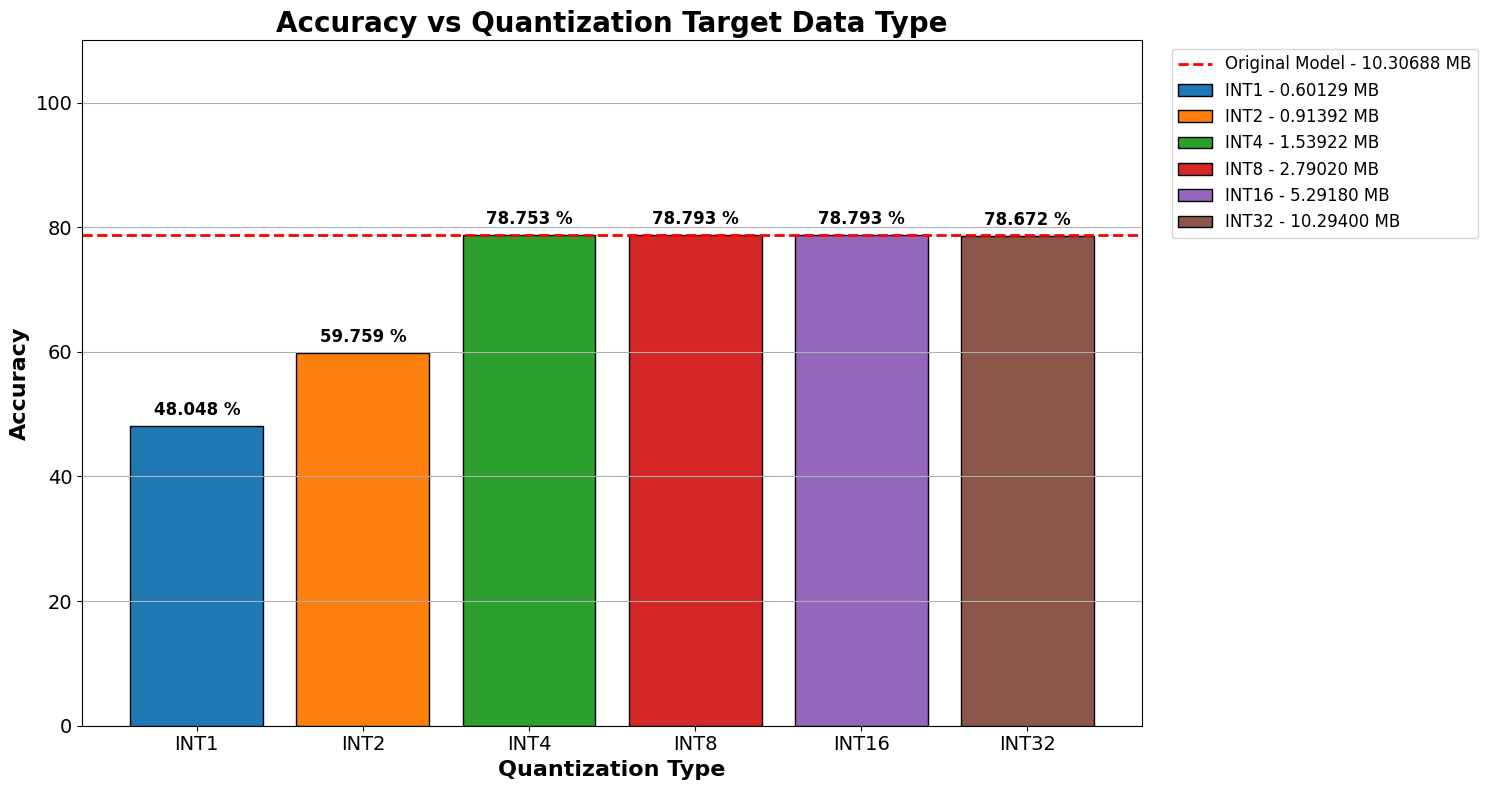

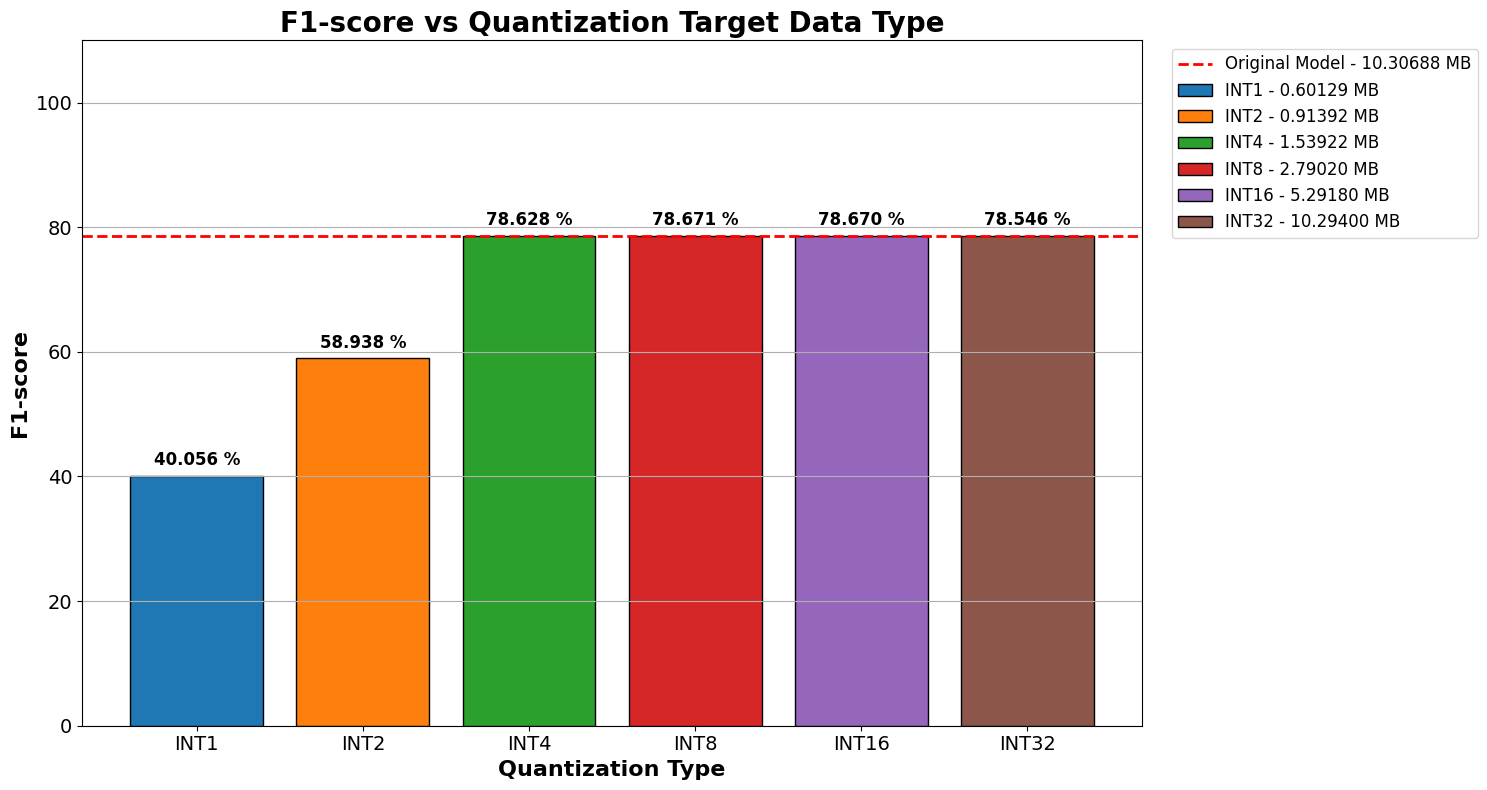

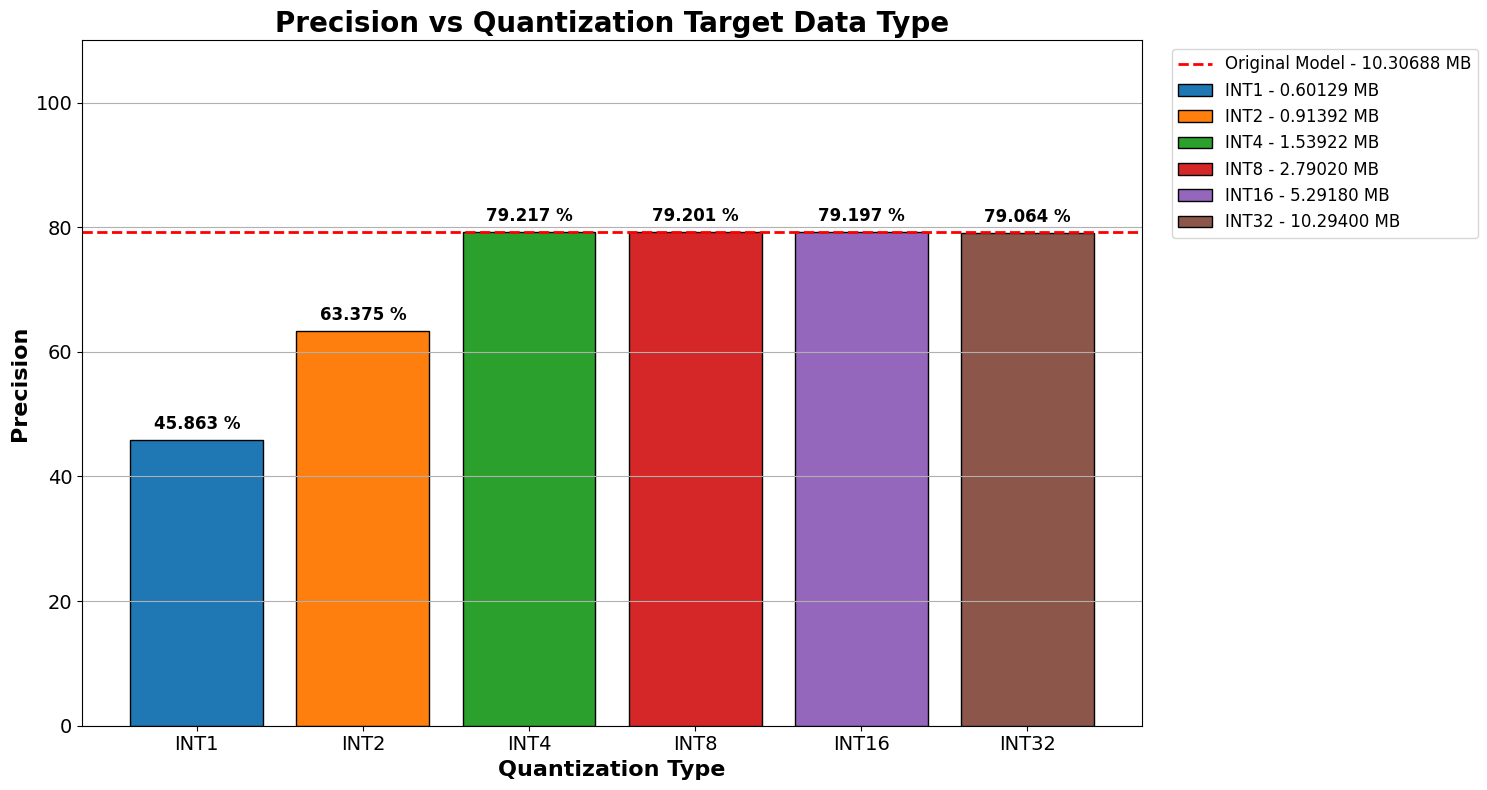

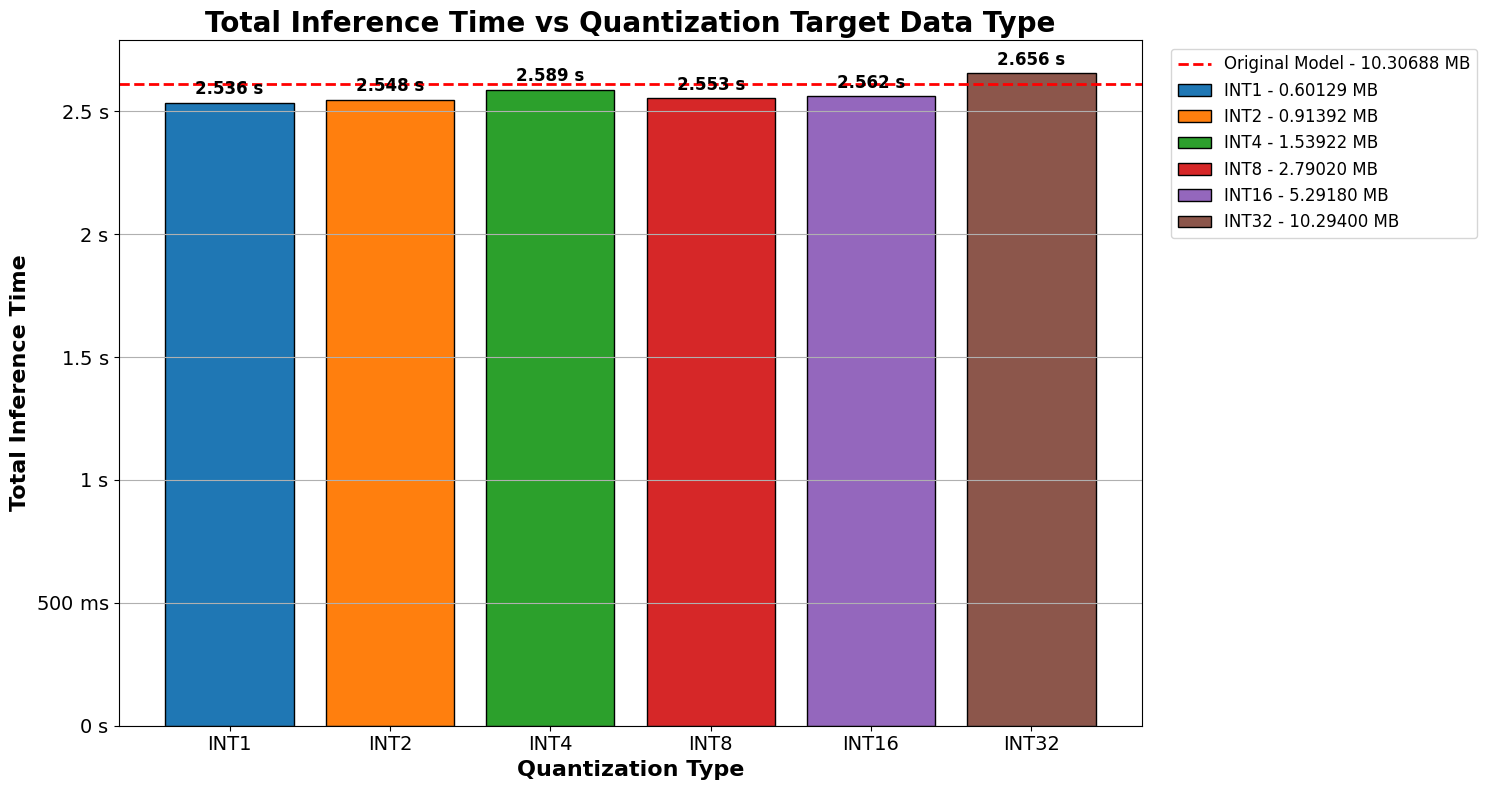

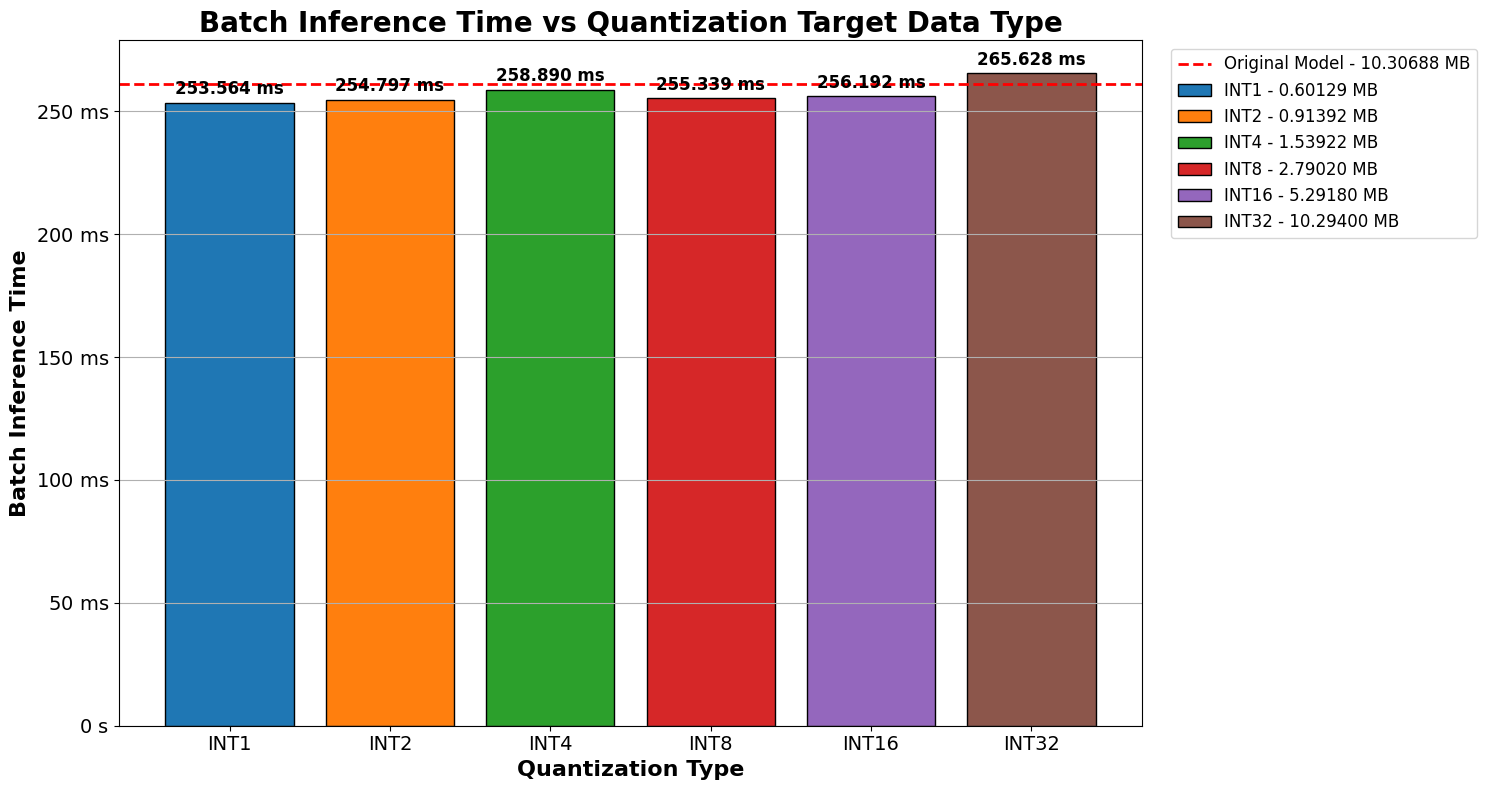

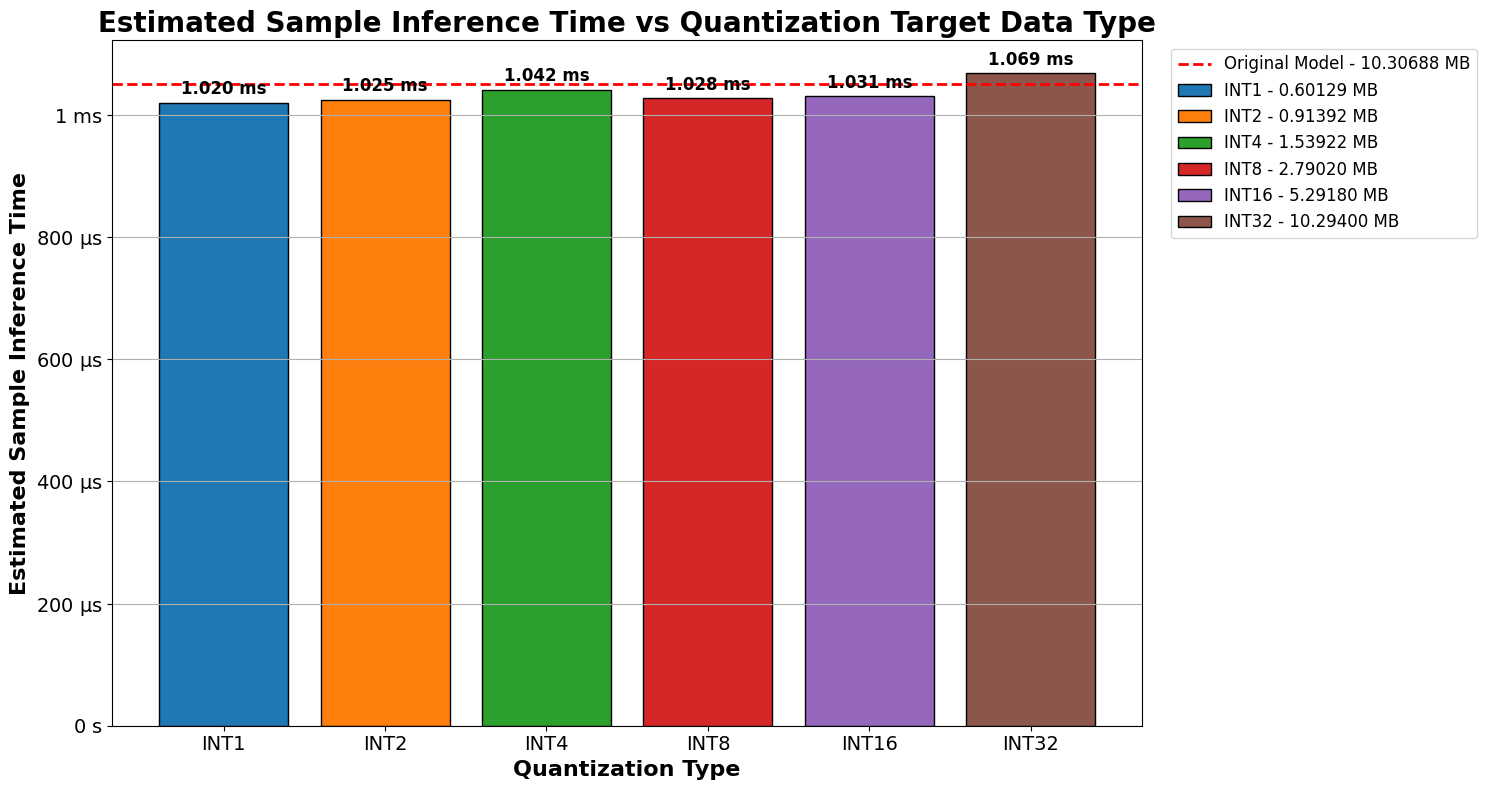

In [22]:
### Evaluate the original model before any modifications
original_metrics = totalEvaulation(
    originalModel,
    test_loader,
    device,
    CM_SaveName="original_model_cm",
    CM_title="Original Model Performance",
    fileName="original_model_metrics",
    show_cm=False
)

### Plotting quantization results with original model baseline ###
quantization_results_df["Quantization Type"] = (
    "INT" + quantization_results_df["Bit Width"].astype(str)
)

plot_quantization_metric_new(
    quantization_results_df,
    metric_name = "Accuracy",
    ylabel = "Accuracy",
    title = "Accuracy",
    save_name = "accuracy_vs_quantization_type.png",
    baseline_value = original_metrics["Accuracy"].iloc[0],
    baseline_memory = original_metrics["Memory footprint"].iloc[0]
)

plot_quantization_metric_new(
    quantization_results_df,
    metric_name = "F1-score",
    ylabel = "F1-score",
    title = "F1-score",
    save_name = "f1_score_vs_quantization_type.png",
    baseline_value = original_metrics["F1-score"].iloc[0],
    baseline_memory = original_metrics["Memory footprint"].iloc[0]
)

plot_quantization_metric_new(
    quantization_results_df,
    metric_name = "Precision",
    ylabel = "Precision",
    title = "Precision",
    save_name = "precision_vs_quantization_type.png",
    baseline_value = original_metrics["Precision"].iloc[0],
    baseline_memory = original_metrics["Memory footprint"].iloc[0]
)
# plot_quantization_metric(
#     quantization_results_df,
#     "Total parameters",
#     "Total Parameters",
#     "parameters_vs_quantization_type.png"
# )

plot_quantization_metric_new(
    quantization_results_df,
    metric_name = "Total Inference time",
    ylabel = "Total Inference Time",
    title = "Total Inference Time",
    save_name = "total_inference_time_vs_quantization_type.png",
    baseline_value = original_metrics["Total Inference time"].iloc[0],
    baseline_memory = original_metrics["Memory footprint"].iloc[0]
)

plot_quantization_metric_new(
    quantization_results_df,
    metric_name = "Batch Inference time",
    ylabel = "Batch Inference Time",
    title = "Batch Inference Time",
    save_name = "batch_inference_time_vs_quantization_type.png",
    baseline_value = original_metrics["Batch Inference time"].iloc[0],
    baseline_memory = original_metrics["Memory footprint"].iloc[0]
)
plot_quantization_metric_new(
    quantization_results_df,
    metric_name = "Est. Sample Inference time",
    ylabel = "Estimated Sample Inference Time",
    title = "Estimated Sample Inference Time",
    save_name = "sample_inference_time_vs_quantization_type.png",
    baseline_value = original_metrics["Est. Sample Inference time"].iloc[0],
    baseline_memory = original_metrics["Memory footprint"].iloc[0]
)


# plot_quantization_metric(
#     quantization_results_df,
#     "Memory footprint",
#     "Memory Footprint (MB)",
#     "memory_footprint_vs_quantization_type.png",
#     baseline_value=original_metrics["Memory footprint"].iloc[0]
# )



## Pruning Part

In [23]:
### Plotting function for pruning metrics
def plot_pruning_metric(df, metric_name, ylabel, save_name, baseline_value=None):
    plt.figure(figsize=(15, 8))
    plt.plot(df["Pruning Ratio"], df[metric_name])


    if metric_name in ["Accuracy", "Precision", "F1-score"]:
        ax = plt.gca()
        plt.ylim(0, 110)
        originalMetric = baseline_value
        x = plt.xlim()[1]*0.4
        #y = plt.ylim()[1]*0.95
        y = baseline_value*1.013
        ax.text(x,y,f"Original Model - {baseline_value:.3f}%",color='red', fontsize=12, fontweight="bold")
    
    if metric_name in ["Est. Sample Inference time", "Batch Inference time","Total Inference time"]:
        ax = plt.gca()
        timeUnit = 's'
        originalMetric = baseline_value
        ax.yaxis.set_major_formatter(mticker.EngFormatter(useMathText=True,unit=timeUnit))
        siTest = si_format(originalMetric,precision=3)
        #x = baseline_value/np.mean(df[metric_name])
        #y = baseline_value/np.mean(df[metric_name][1])*1.2
        x = plt.xlim()[1]*0.4
        #y = plt.ylim()[1]*0.95
        y = baseline_value*1.013
        ax.text(x,y,f"Original Model - {siTest}s",color='red', fontsize=12, fontweight="bold")


    if metric_name in ["Memory footprint"]:
        ax = plt.gca()
        sizeUnit = 'MB'
        originalMetric = baseline_value
        ax.yaxis.set_major_formatter(mticker.EngFormatter(useMathText=True,unit=sizeUnit))
        siTest = si_format(originalMetric,precision=3)
        x = plt.xlim()[1]*0.4
        #y = plt.ylim()[1]*0.95
        y = baseline_value*1.013
        ax.text(x,y,f"Original Model - {siTest} MB",color='red', fontsize=12, fontweight="bold")
    
    if metric_name in ["Total parameters"]:
        ax = plt.gca()
        #sizeUnit = 'M'
        originalMetric = baseline_value
        #ax.yaxis.set_major_formatter(mticker.EngFormatter(useMathText=True,unit=sizeUnit))
        siTest = si_format(originalMetric,precision=3)
        x = plt.xlim()[1]*0.4
        #y = plt.ylim()[1]*0.95
        y = baseline_value*1.013
        ax.text(x,y,f"Original Model - {siTest} params",color='red', fontsize=12, fontweight="bold")

    if baseline_value is not None:
        plt.axhline(
            y=baseline_value,
            color="red",
            linestyle="--",
            linewidth=2,
            label="Original Model"
        )
        plt.legend(fontsize=14, loc="upper right")
        
    plt.yticks(fontsize=14)
    plt.xticks(rotation=0, fontsize=14)
    #plt.xlabel(metric_name)
    plt.ylabel(ylabel, fontsize=16, fontweight="bold")
    
    plt.xlabel("Pruning Ratio", fontsize=16, fontweight="bold")
    plt.xlim(0,1)
    #plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs Pruning Ratio",fontsize=20, fontweight="bold")
    
    #if "Inference" in metric_name:
    #    #ax = plt.gca()
    #    testMetric = np.mean(df[metric_name])
    #    siTest = si_format(testMetric, precision=5) # Getting both the time and the unit prefix
    #    spliSI = siTest.split(" ")[0] # Getting only the time, use [1] for unit prefix
    #    print(f"Mean {metric_name}: {testMetric:.4f} s | SI formatted: {siTest} | SI value: {spliSI}")
    #    timeUnit = "s"
    #    ax = plt.gca()
    #    ax.yaxis.set_major_formatter(mticker.EngFormatter(useMathText=True, unit=timeUnit))
    #    plt.ylabel(f"{ylabel}")
    #    #formatter = ScalarFormatter(useMathText=True)
    #    #formatter.set_scientific(True)
    #    #formatter.set_powerlimits((-3, 3))
#
    #    #ax.yaxis.set_major_formatter(formatter)
        
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_name, dpi=800, bbox_inches="tight")
    plt.show()

In [24]:
### Applying Pruning Only #####

# pruningRatio = 0.4
# prunedModel = structured_prune_ffn(modelForPruning, amount=pruningRatio)
# rebuiltModel = rebuild_model_pruned(prunedModel, threshold=0.0)
# totalEvaulation(rebuiltModel, test_loader, device, CM_SaveName="pruned_model_cm",CM_title = "Pruned Model Performance Evaluation", fileName = "pruned_model_metrics")
#pruning_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

pruning_ratios = np.arange(1,100)
#pruning_ratios = np.arange(1,100,10)
importance_scores = compute_gradient_importance_scores(originalModel,val_loader,device,)
pruning_results_df = pruning_ratio_experiment(
    originalModel,
    test_loader,
    device,
    pruning_ratios/100,
    output_csv="pruning_ratio_metrics.csv",
    importances=importance_scores
)



Pruning ratio: 0.01
Rebuilt Transformer FFN dims per encoder layer: [507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507, 507]

Pruning ratio: 0.02
Rebuilt Transformer FFN dims per encoder layer: [502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502]

Pruning ratio: 0.03
Rebuilt Transformer FFN dims per encoder layer: [497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497]

Pruning ratio: 0.04
Rebuilt Transformer FFN dims per encoder layer: [492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492]

Pruning ratio: 0.05
Rebuilt Transformer FFN dims per encoder layer: [486, 486, 

KeyboardInterrupt: 

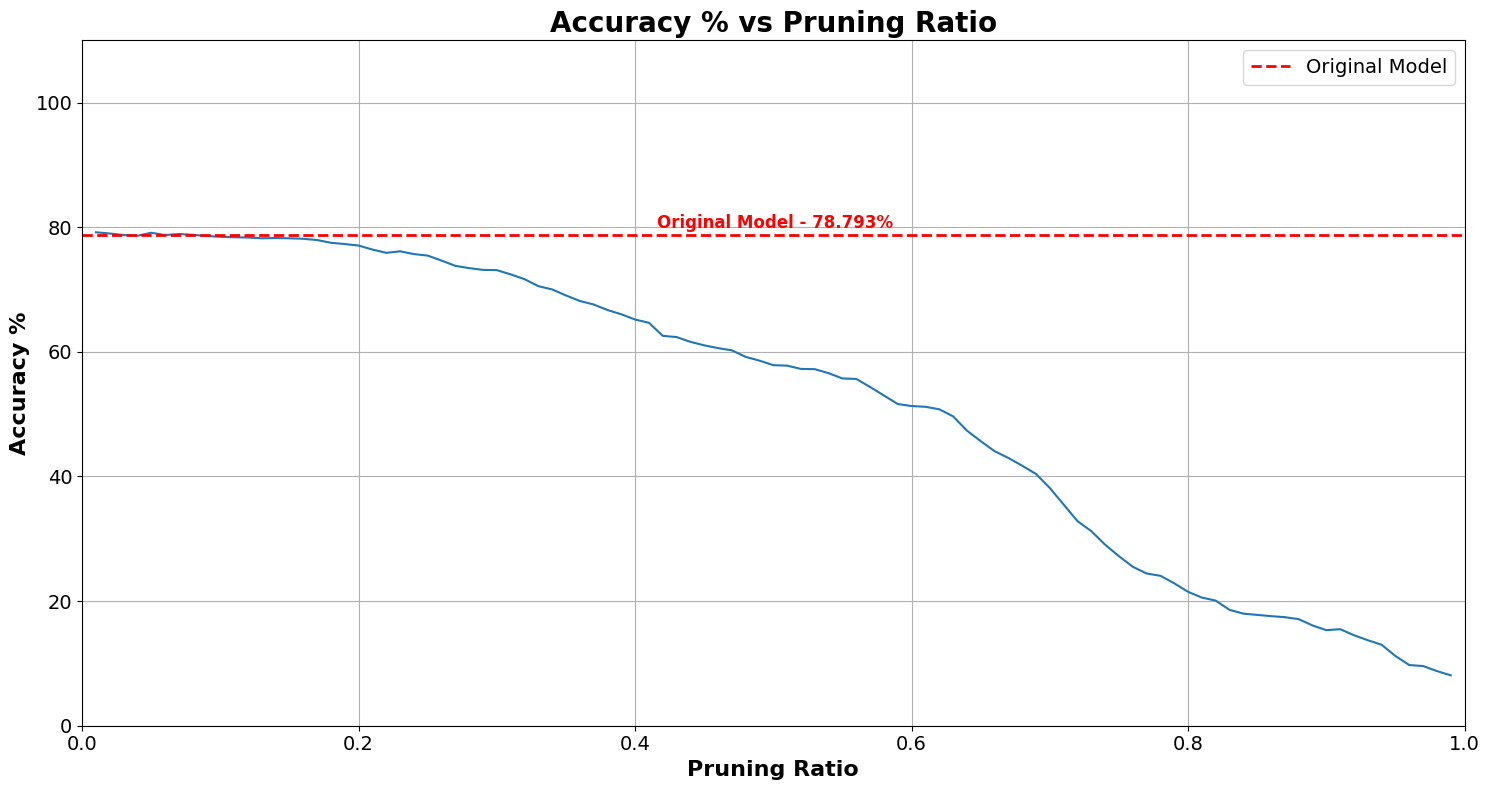

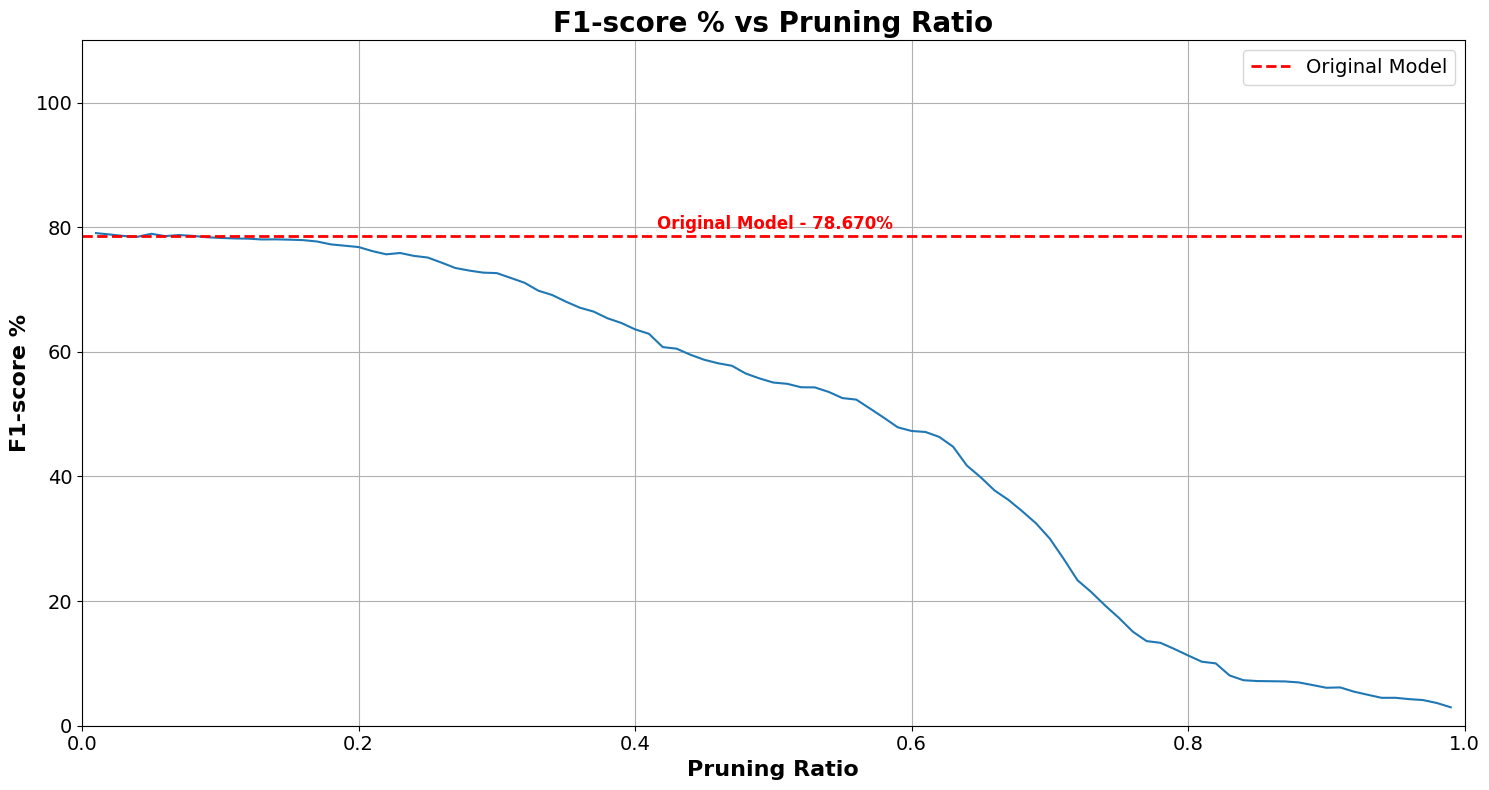

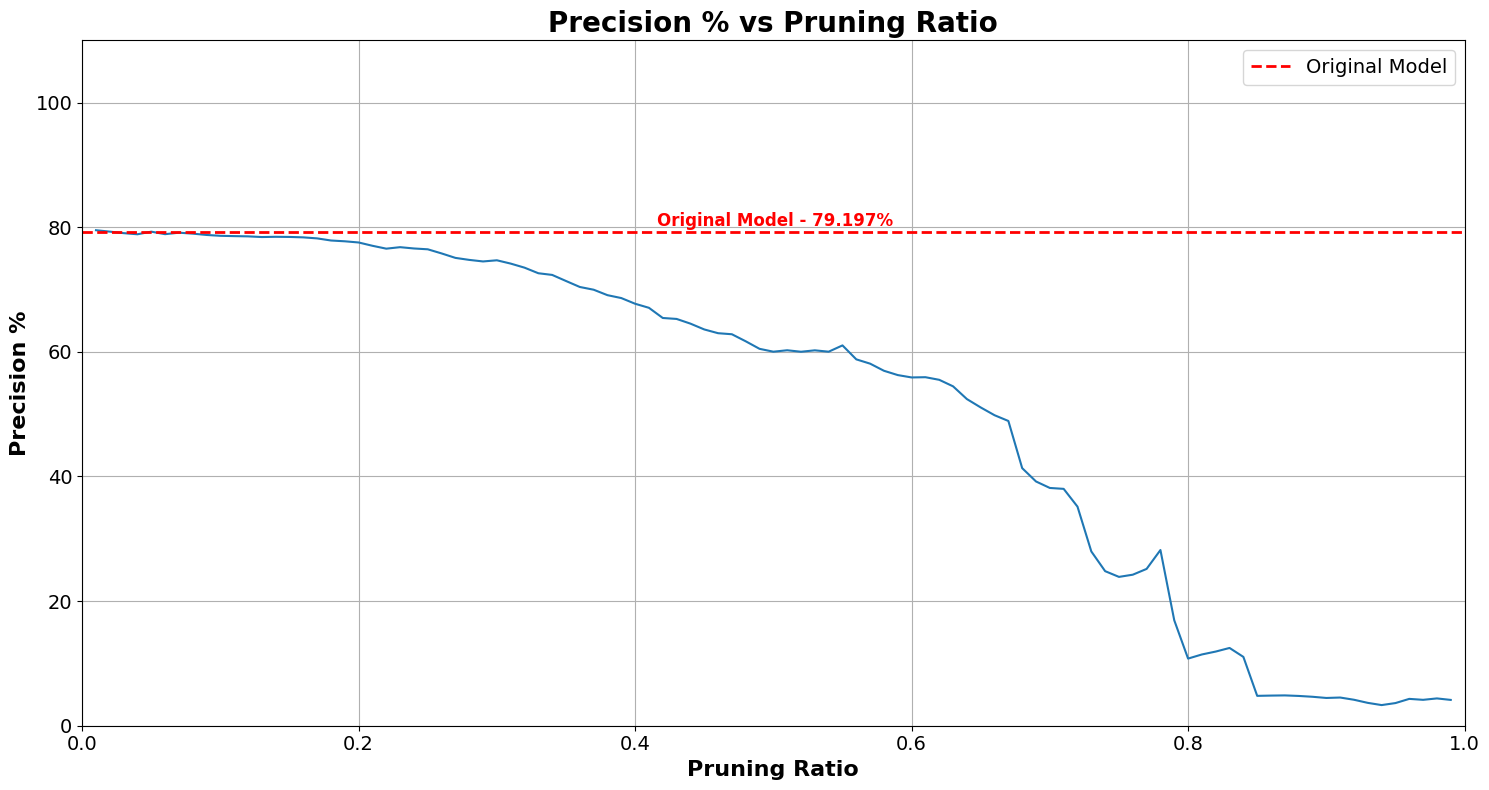

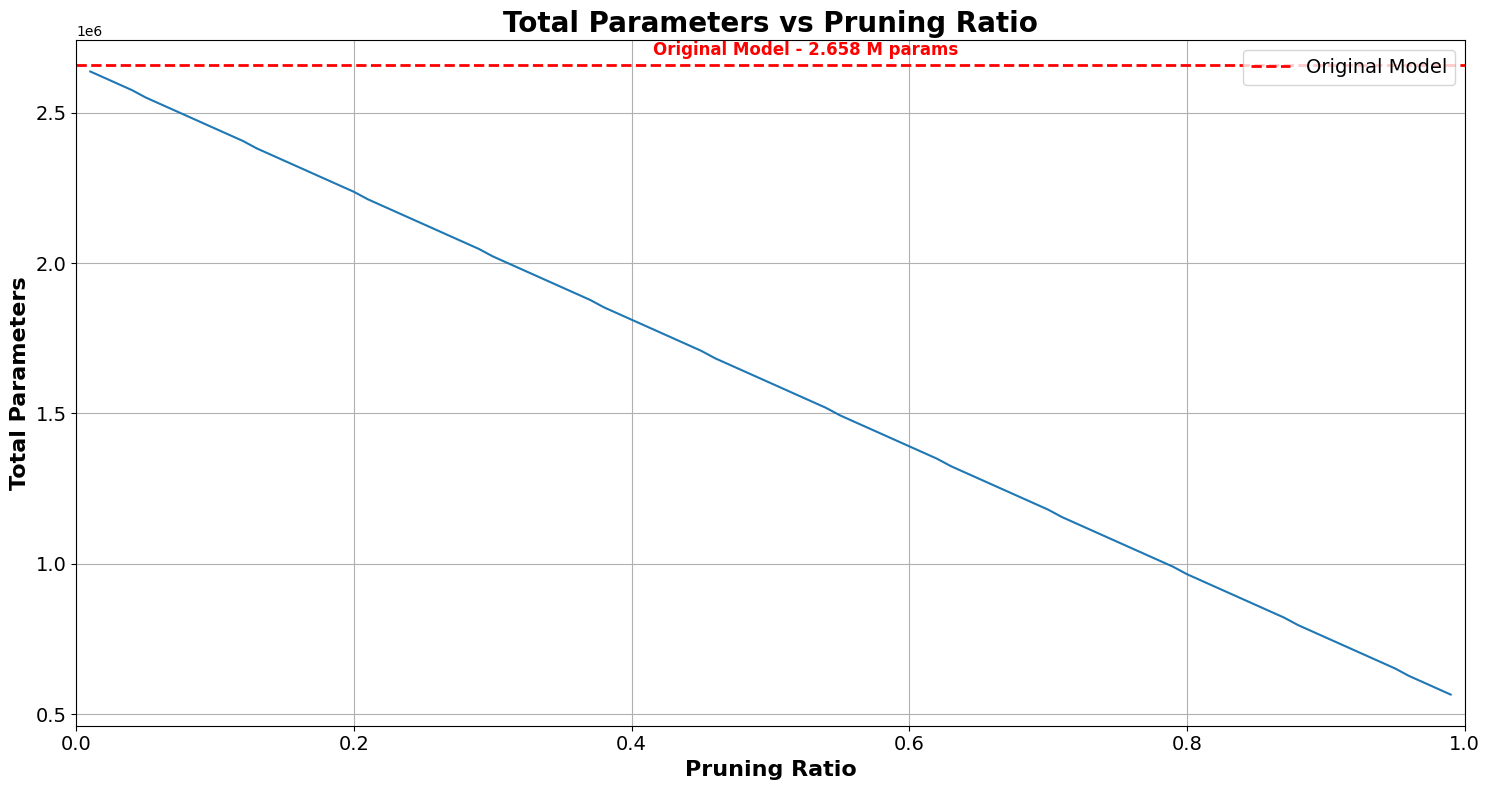

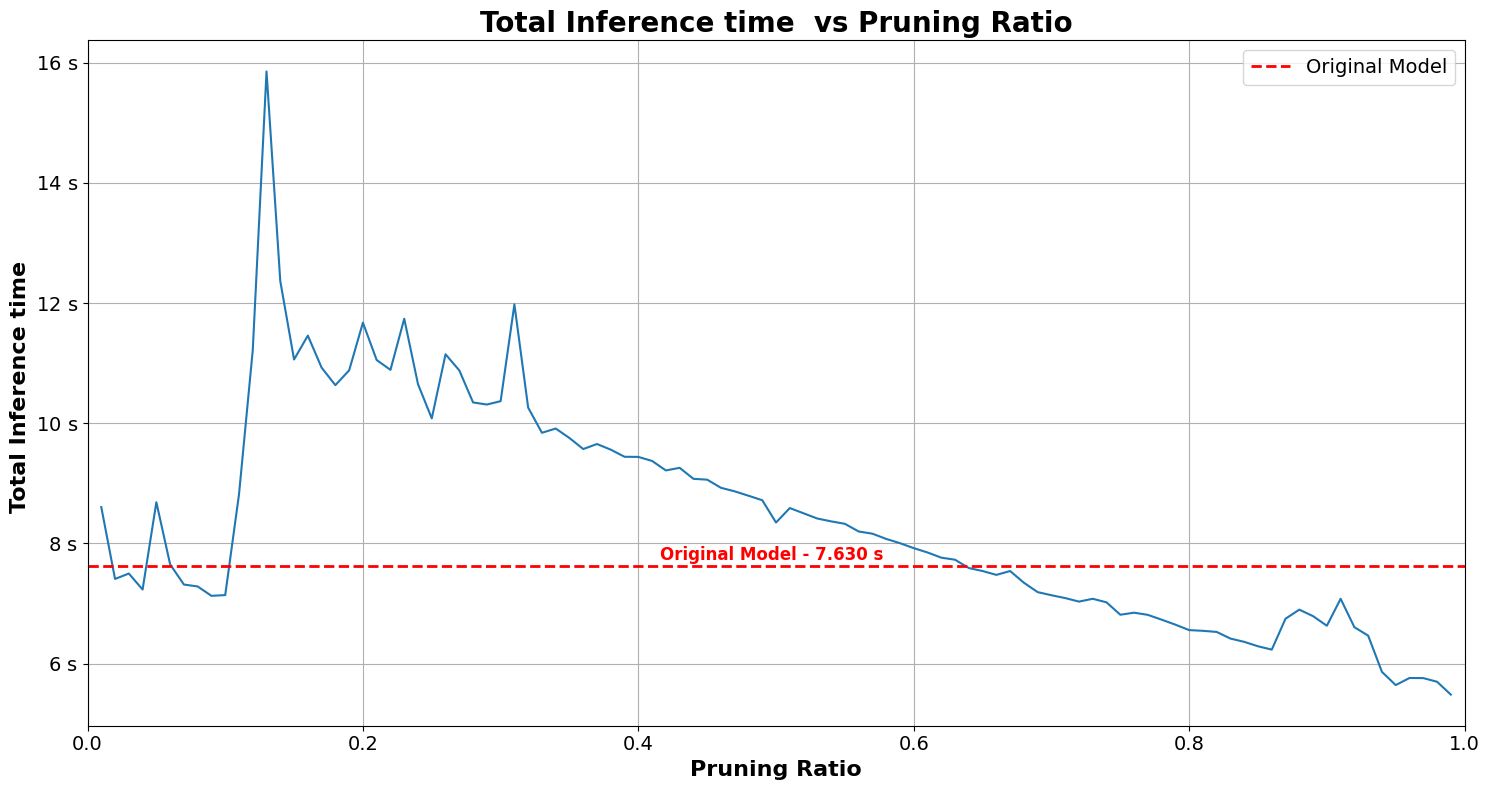

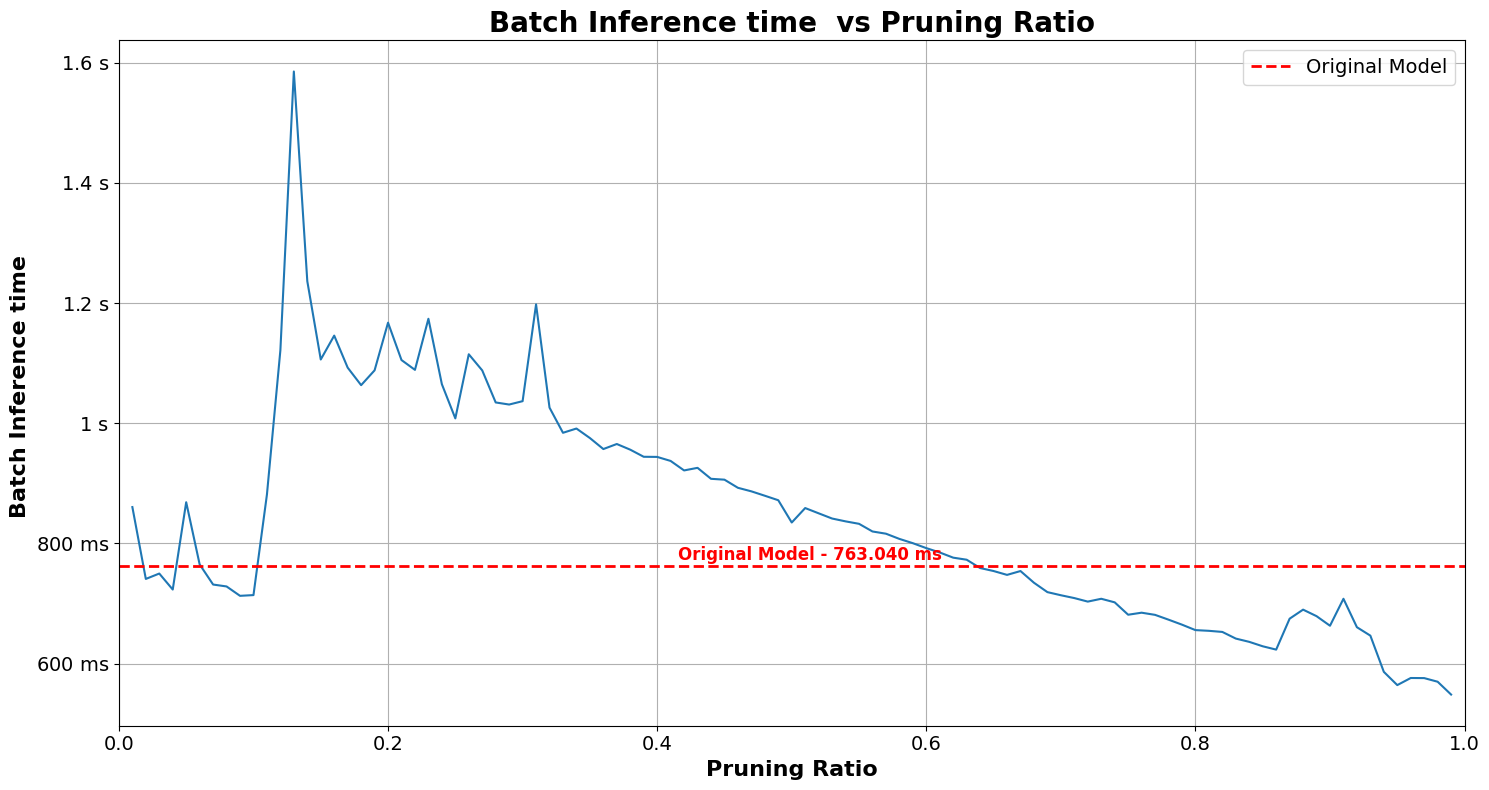

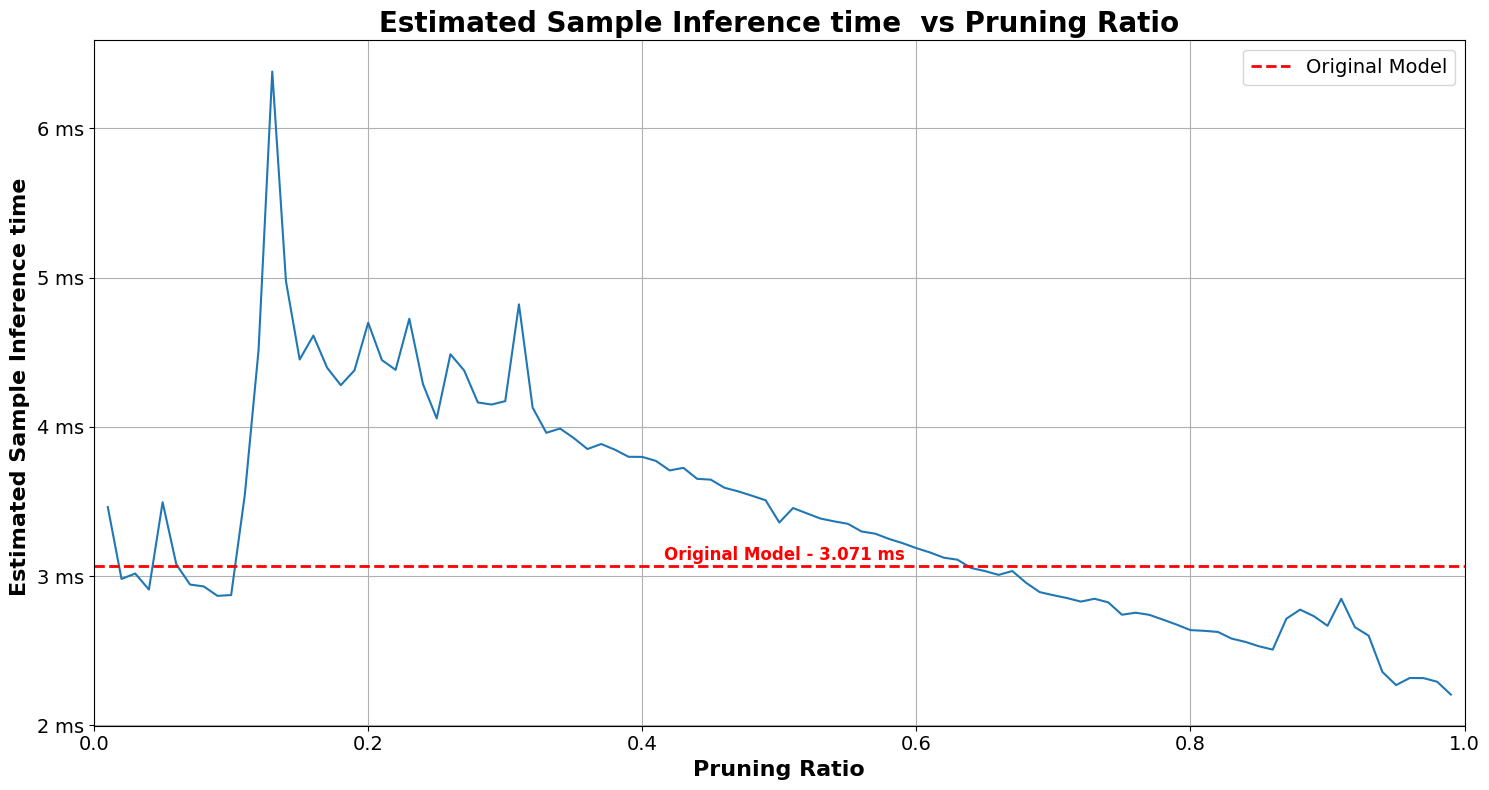

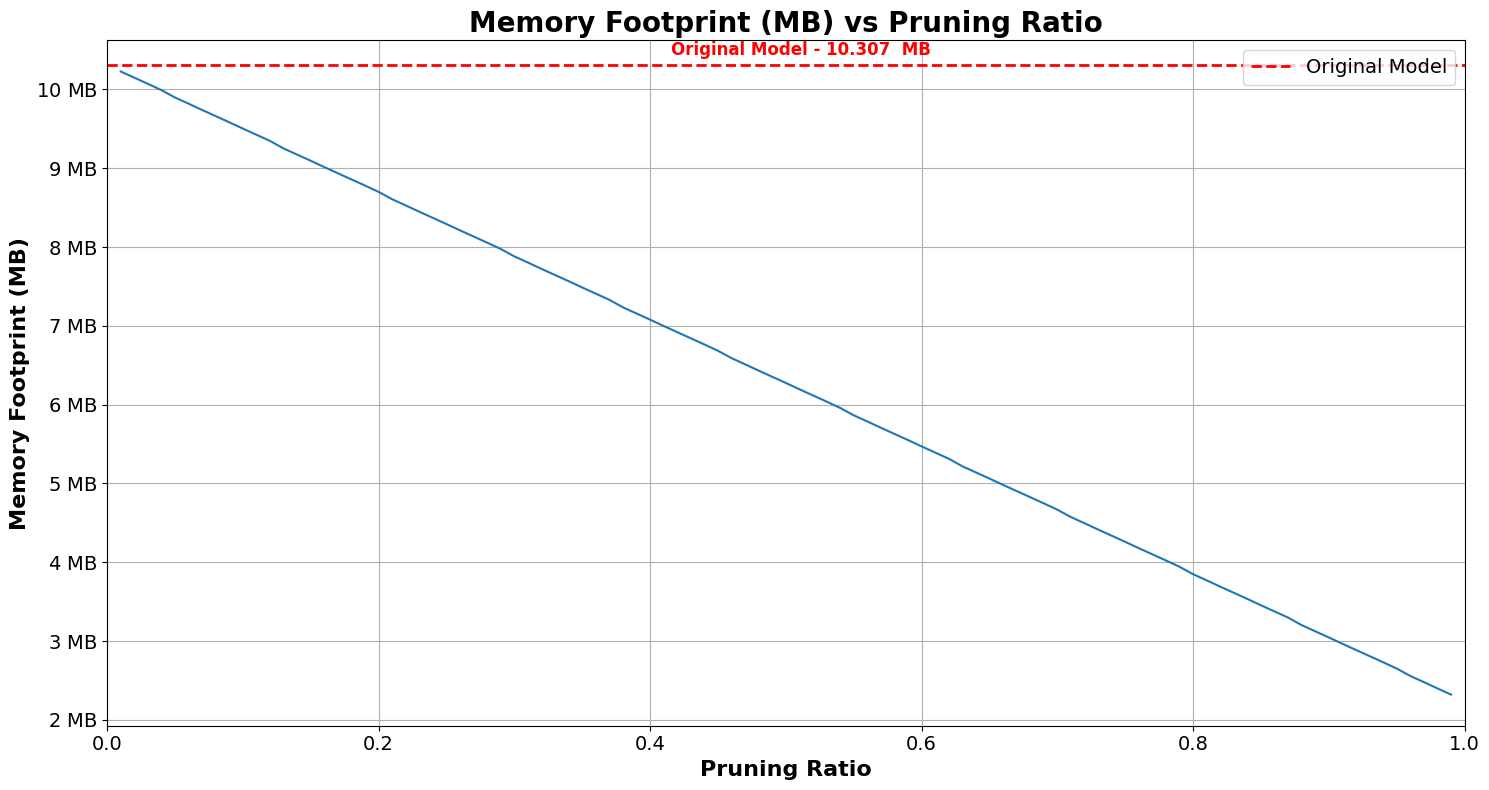

In [ ]:
#### Plotting Pruning Results ####
#pruning_results_df = pd.read_csv("pruning_ratio_metrics.csv")
original_metrics = pd.read_pickle("original_model_metrics.pkl")
plot_pruning_metric(
    pruning_results_df,
    "Accuracy",
    "Accuracy %",
    "Accuracy_vs_Pruning_ratio.png",
    baseline_value=original_metrics["Accuracy"].iloc[0]
    
)

plot_pruning_metric(
    pruning_results_df,
    "F1-score",
    "F1-score %",
    "f1_score_vs_pruning_ratio.png",
    baseline_value=original_metrics["F1-score"].iloc[0]
)

plot_pruning_metric(
    pruning_results_df,
    "Precision",
    "Precision %",
    "precision_vs_pruning_ratio.png",
    baseline_value=original_metrics["Precision"].iloc[0]
)


plot_pruning_metric(
    pruning_results_df,
    "Total parameters",
    "Total Parameters",
    "parameters_vs_pruning_ratio.png",
    baseline_value=original_metrics["Total parameters"].iloc[0]
)

plot_pruning_metric(
    pruning_results_df,
    "Total Inference time",
    "Total Inference time ",
    "total_inference_time__pruning_ratio.png",
    baseline_value=original_metrics["Total Inference time"].iloc[0]
)

plot_pruning_metric(
    pruning_results_df,
    "Batch Inference time",
    "Batch Inference time ",
    "batch_inference_time__pruning_ratio.png",
    baseline_value=original_metrics["Batch Inference time"].iloc[0]
)
plot_pruning_metric(
    pruning_results_df,
    "Est. Sample Inference time",
    "Estimated Sample Inference time ",
    "sample_inference_time__pruning_ratio.png",
    baseline_value=original_metrics["Est. Sample Inference time"].iloc[0]
)


plot_pruning_metric(
    pruning_results_df,
    "Memory footprint",
    "Memory Footprint (MB)",
    "memory_footprint_vs_pruning_ratio.png",
    baseline_value=original_metrics["Memory footprint"].iloc[0]
)




# Pipeline part of the code where the two compression techniques are tested in sequence. 


## This part will look into Quantize-Prune 

In [ ]:
def quant_then_prune(model,bitwidths, pruning_ratios,val_loader,test_loader, device):
    results = []
    for bitwidth in bitwidths:
        save_path = f"manual_int{bitwidth}.pth"
        save_quantized_model(
            model,
            save_path,
            bitwidth
        )
        quantized_model = load_quantized_model(
            model,
            save_path,
            device
        )
        currentImportanceScore = compute_gradient_importance_scores(quantized_model, val_loader, device)

        pruned_model_df = pruning_ratio_experiment(quantized_model, 
                                                   test_loader, 
                                                   device, 
                                                   pruning_ratios/100, 
                                                   currentImportanceScore, 
                                                   output_csv=f"quantized_pruned_metrics_int{bitwidth}.csv")
        """
        rebuilt_model = rebuild_model_pruned(pruned_model, threshold=0.0)
        metrics_df = totalEvaulation(
            rebuilt_model,
            test_loader,
            device,
            CM_SaveName=f"quantized_pruned_cm_{bitwidth}",
            CM_title=f"Quantized (INT{bitwidth}) + Pruned Model Performance",
            fileName=f"quantized_pruned_metrics_int{bitwidth}",
            show_cm=False
        )
        """
        pruned_model_df["Bit Width"] = bitwidth
        #metrics_df["Pruning Ratio"] = ratio
        pruned_model_df["Memory footprint"] = get_model_size_mb(save_path)
        pruned_model_df["Quantization Type"] = f"INT{bitwidth}"
        results.append(pruned_model_df)
    combined_results_df = pd.concat(results, ignore_index=True)
    combined_results_df.to_csv("quantized_then_pruned_results.csv", index=False)
    return combined_results_df
    

In [ ]:
#importances = compute_gradient_importance_scores(originalModel, val_loader, device)
pruning_ratios = np.arange(1,100,1)
bitwidths = [1, 2, 4, 8, 16, 32]
quant_prune_results_df = quant_then_prune(
    originalModel,
    bitwidths,
    pruning_ratios,
    val_loader,
    test_loader,
    device
)


Pruning ratio: 0.01
Rebuilt Transformer FFN dims per encoder layer: [482, 507, 507, 507, 507, 504, 507, 507, 507, 506, 505, 507, 492, 507, 493, 507, 491, 480, 505, 496, 450, 504, 472, 458, 472, 501, 479, 483, 487, 485, 490, 474]

Pruning ratio: 0.02
Rebuilt Transformer FFN dims per encoder layer: [482, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 492, 502, 493, 502, 491, 480, 502, 496, 450, 502, 472, 458, 472, 501, 479, 483, 487, 485, 490, 474]

Pruning ratio: 0.03
Rebuilt Transformer FFN dims per encoder layer: [482, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 492, 497, 493, 497, 491, 480, 497, 496, 450, 497, 472, 458, 472, 497, 479, 483, 487, 485, 490, 474]

Pruning ratio: 0.04
Rebuilt Transformer FFN dims per encoder layer: [482, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 491, 480, 492, 492, 450, 492, 472, 458, 472, 492, 479, 483, 487, 485, 490, 474]

Pruning ratio: 0.05
Rebuilt Transformer FFN dims per encoder layer: [482, 486, 

In [ ]:
import winsound

winsound.PlaySound("Finished.wav", winsound.SND_FILENAME)

In [ ]:
#### Plotting combined quantization + pruning results ####
def plotPruningNew(csvName,bitWidths,metric_name,plotTitle, pruningRatios, original_metrics, save_name):
    accDf = pd.DataFrame()
    # other dfs kept for compatibility if needed later
    f1Df = pd.DataFrame()
    precDf = pd.DataFrame()
    timeDf = pd.DataFrame()
    memoryDf = pd.DataFrame()
    paramDf = pd.DataFrame()
    

    for i in bitWidths:
        localDF = pd.read_csv(f"{csvName}_int{i}.csv")

        # determine index for rows: prefer "Pruning Ratio" column if present, else use passed pruningRatios scaled to [0,1]
        if "Pruning Ratio" in localDF.columns:
            idx = localDF["Pruning Ratio"].values
        else:
            idx = (pruningRatios / 100.0)

        # Add Accuracy column named by bitwidth
        acc_series = pd.Series(localDF["Accuracy"].values, index=idx, name=f"INT{i}")
        accDf = pd.concat([accDf, acc_series], axis=1)

        # collect other metrics if needed (keeps same indexing)
        if "F1-score" in localDF.columns:
            f1Df = pd.concat([f1Df, pd.Series(localDF["F1-score"].values, index=idx, name=f"INT{i}")], axis=1)
        if "Precision" in localDF.columns:
            precDf = pd.concat([precDf, pd.Series(localDF["Precision"].values, index=idx, name=f"INT{i}")], axis=1)
        if "Est. Sample Inference time" in localDF.columns:
            timeDf = pd.concat([timeDf, pd.Series(localDF["Est. Sample Inference time"].values, index=idx, name=f"INT{i}")], axis=1)
        if "Memory footprint" in localDF.columns:
            memoryDf = pd.concat([memoryDf, pd.Series(localDF["Memory footprint"].values, index=idx, name=f"INT{i}")], axis=1)
        if "Total parameters" in localDF.columns:
            paramDf = pd.concat([paramDf, pd.Series(localDF["Total parameters"].values, index=idx, name=f"INT{i}")], axis=1)
            
            
    plt.figure(figsize=(15, 8))        
    if metric_name in ["Accuracy", "Precision", "F1-score"]:
        ax = plt.gca()
        for col in accDf.columns:
            plt.plot(pruningRatios, accDf[col], label=col)
        plt.axhline(
            y=original_metrics[metric_name].iloc[0],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Original Model"
        )
        x = plt.xlim()[1]*0.4
        y = original_metrics[metric_name].iloc[0]*1.013
        ax.text(
            x,
            y,
            f"Original Model - {original_metrics[metric_name].iloc[0]:.3f}%",
            color='red',
            fontsize=12,
            fontweight="bold"
        )
        plt.xlabel("Pruning Ratio", fontsize=16, fontweight="bold")
        plt.ylabel(f"{metric_name} (%)", fontsize=16, fontweight="bold")
        plt.title(f"{plotTitle}", fontsize=20, fontweight="bold")
        plt.savefig(save_name, dpi=800, bbox_inches="tight")
    
    
    #### SI formatting for inference time plots
    if metric_name in ["Est. Sample Inference time", "Batch Inference time","Total Inference time"]:
        ax = plt.gca()
        timeUnit = 's'
        ax.yaxis.set_major_formatter(mticker.EngFormatter(useMathText=True, unit=timeUnit))
        for col in timeDf.columns:
            plt.plot(pruningRatios, timeDf[col], label=col)
        #plt.axhline(
            #y=original_metrics[metric_name].iloc[0],
            #color="red",
            #linestyle="--",
            #linewidth=2,
            #label="Original Model"
        #)
        x = plt.xlim()[1]*0.4
        y = plt.ylim()[1]*0.95
        siTest = si_format(original_metrics[metric_name].iloc[0], precision=3)
        ax.text(
            x,
            y,
            f"Original Model - {siTest}s",
            color='red',
            fontsize=12,
            fontweight="bold"
        )
        plt.xlabel("Pruning Ratio", fontsize=16, fontweight="bold")
        plt.ylabel(f"{metric_name}", fontsize=16, fontweight="bold")
        plt.title(f"{plotTitle}", fontsize=20, fontweight="bold")
        plt.savefig(save_name, dpi=800, bbox_inches="tight")
        
        
    if metric_name in ["Memory footprint"]:
        ax = plt.gca()
        for col in memoryDf.columns:
            plt.plot(pruningRatios, memoryDf[col], label=col)
        plt.axhline(
            y=original_metrics[metric_name].iloc[0],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Original Model"
        )
        x = plt.xlim()[1]*0.4
        y = original_metrics[metric_name].iloc[0]*0.97
        ax.text(
            x,
            y,
            f"Original Model - {original_metrics[metric_name].iloc[0]:.3f} MB",
            color='red',
            fontsize=12,
            fontweight="bold"
        )
        plt.xlabel("Pruning Ratio", fontsize=16, fontweight="bold")
        plt.ylabel(f"{metric_name} (MB)", fontsize=16, fontweight="bold")
        plt.title(f"{plotTitle}", fontsize=20, fontweight="bold")
        plt.savefig(save_name, dpi=800, bbox_inches="tight")
    
    if metric_name in ["Total parameters"]:
        ax = plt.gca()
        for col in paramDf.columns:
            plt.plot(pruningRatios, paramDf[col], label=col)
        plt.axhline(
            y=original_metrics[metric_name].iloc[0],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Original Model"
        )
        x = plt.xlim()[1]*0.4
        y = original_metrics[metric_name].iloc[0]*0.97
        siTest = si_format(original_metrics[metric_name].iloc[0], precision=3)
        ax.text(
            x,
            y,
            f"Original Model - {siTest} params",
            color='red',
            fontsize=12,
            fontweight="bold"
        )
        plt.xlabel("Pruning Ratio", fontsize=16, fontweight="bold")
        plt.ylabel(f"{metric_name}", fontsize=16, fontweight="bold")
        plt.title(f"{plotTitle}", fontsize=20, fontweight="bold")
        plt.savefig(save_name, dpi=800, bbox_inches="tight")
    
    plt.xticks(rotation=0, fontsize=14)
    plt.yticks(fontsize=14)
    
    plt.legend(fontsize=12, loc="upper right")
    plt.grid(True,alpha=0.3)
    plt.tight_layout()


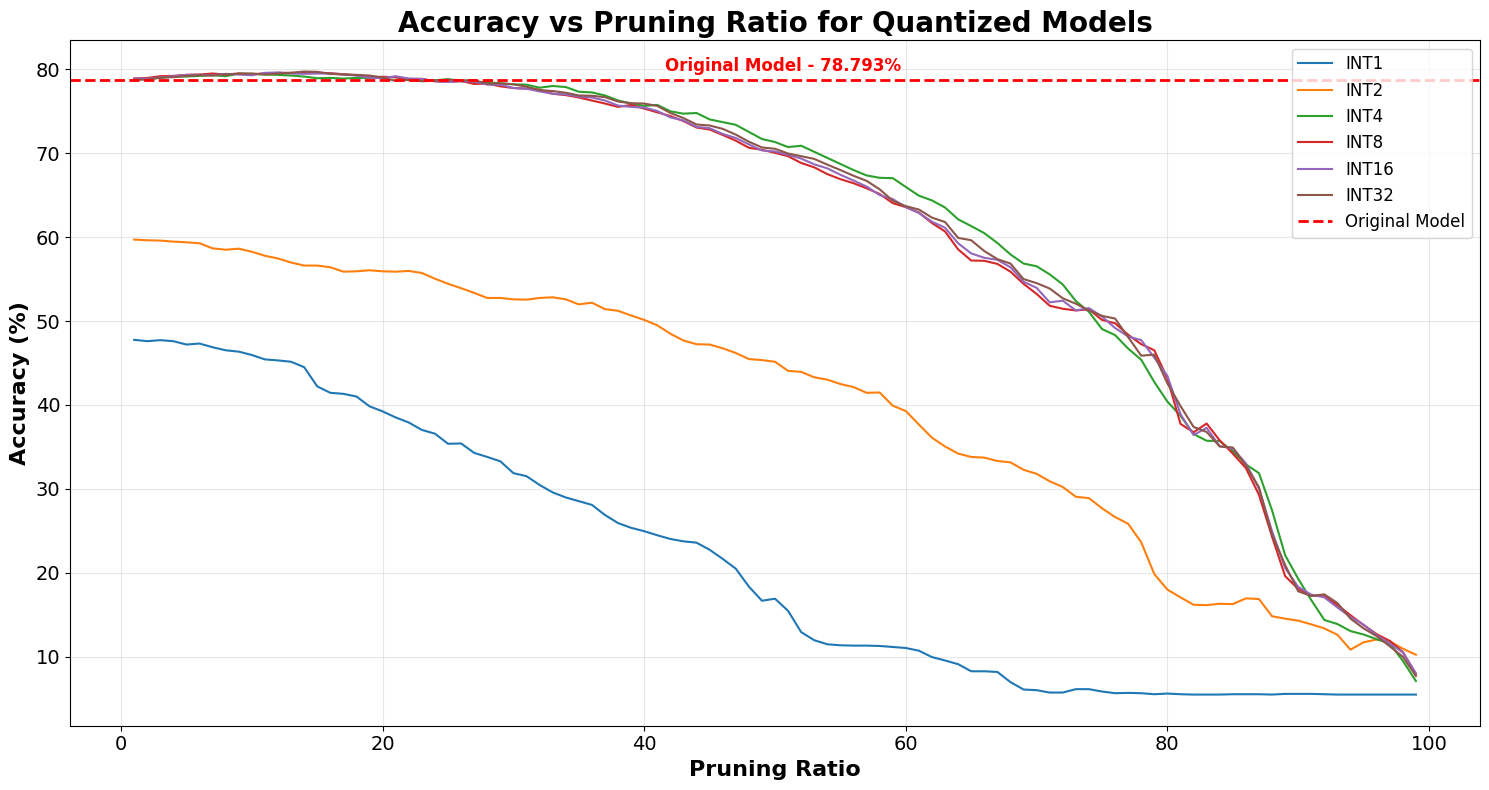

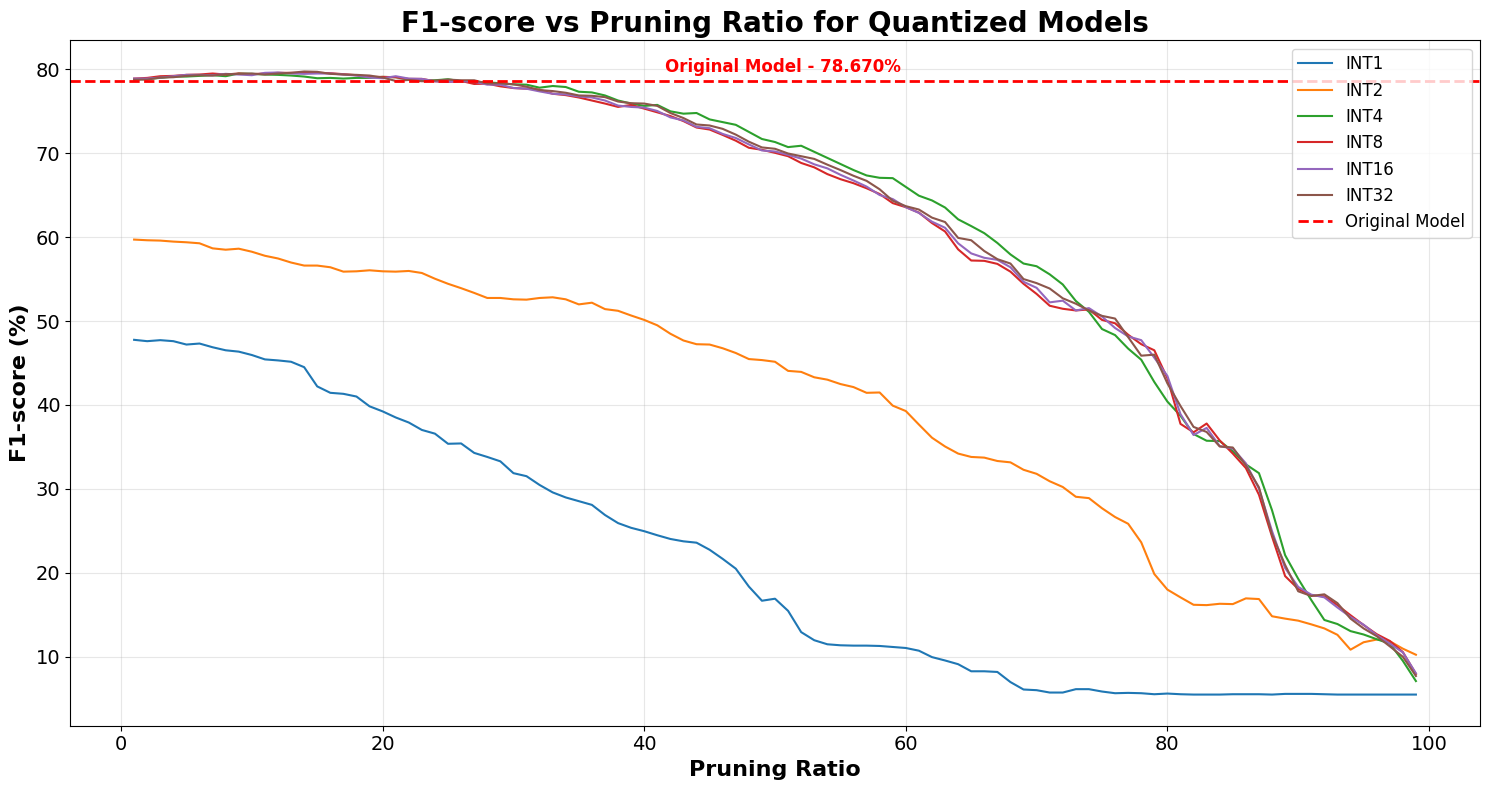

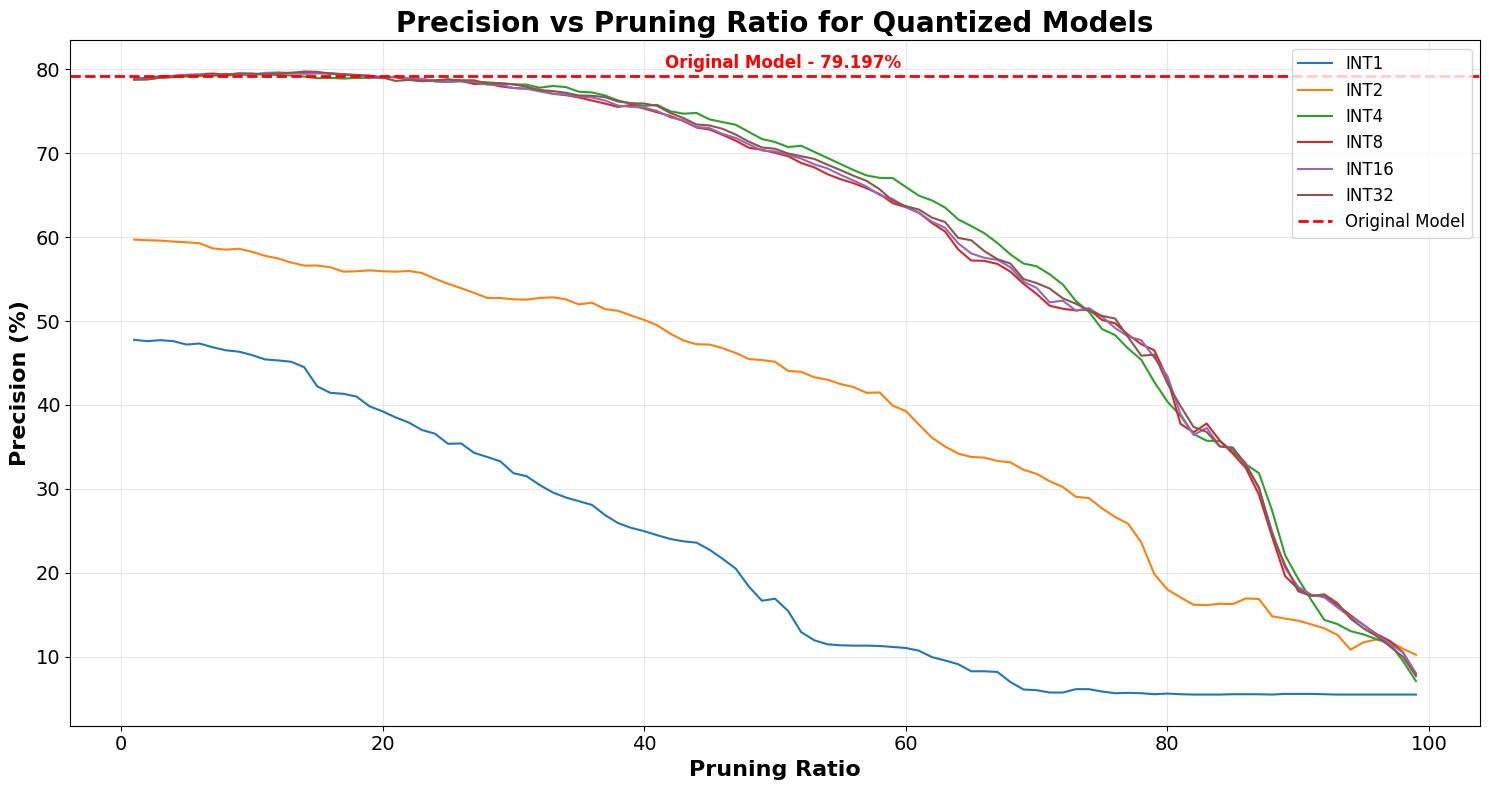

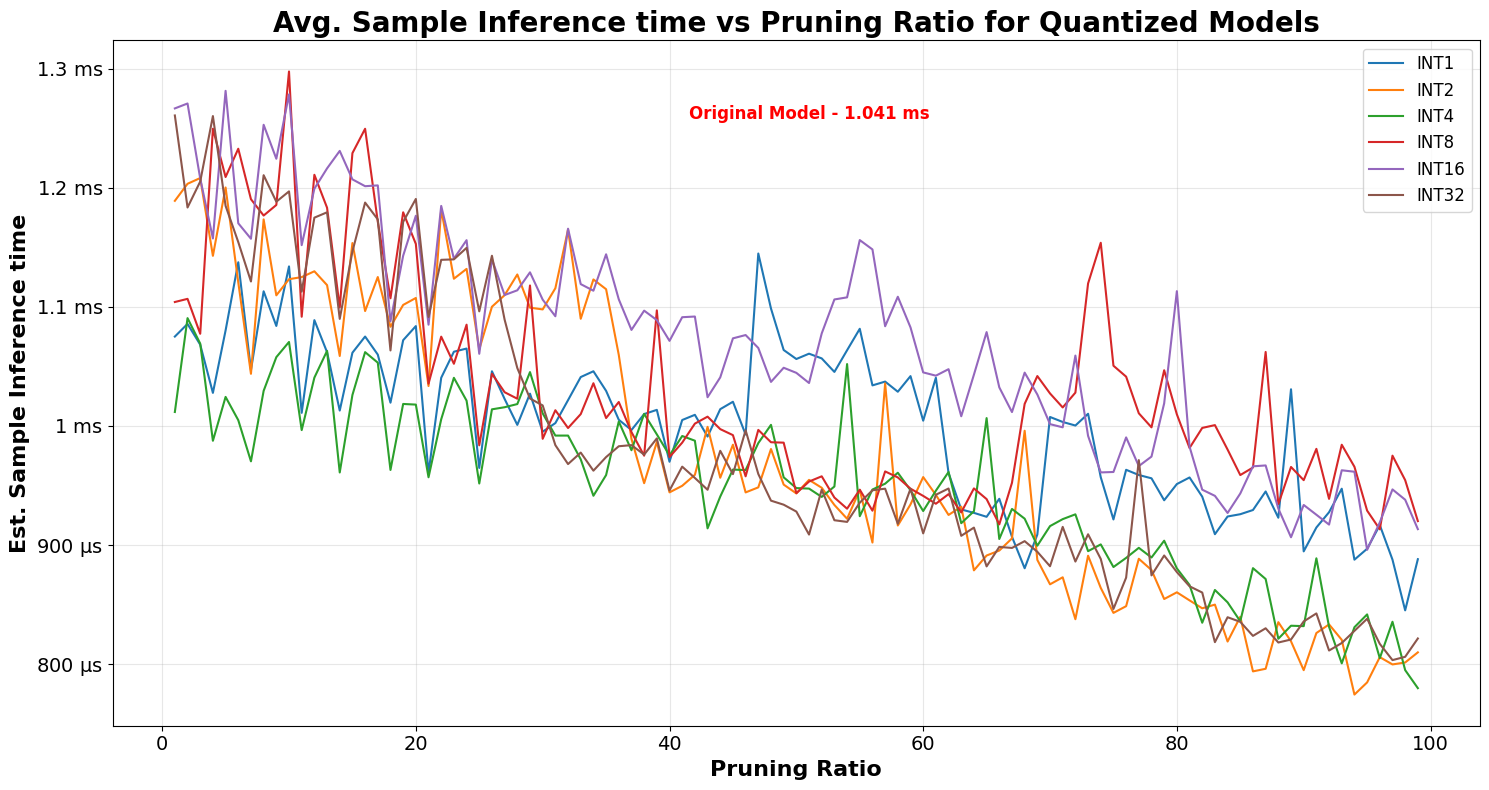

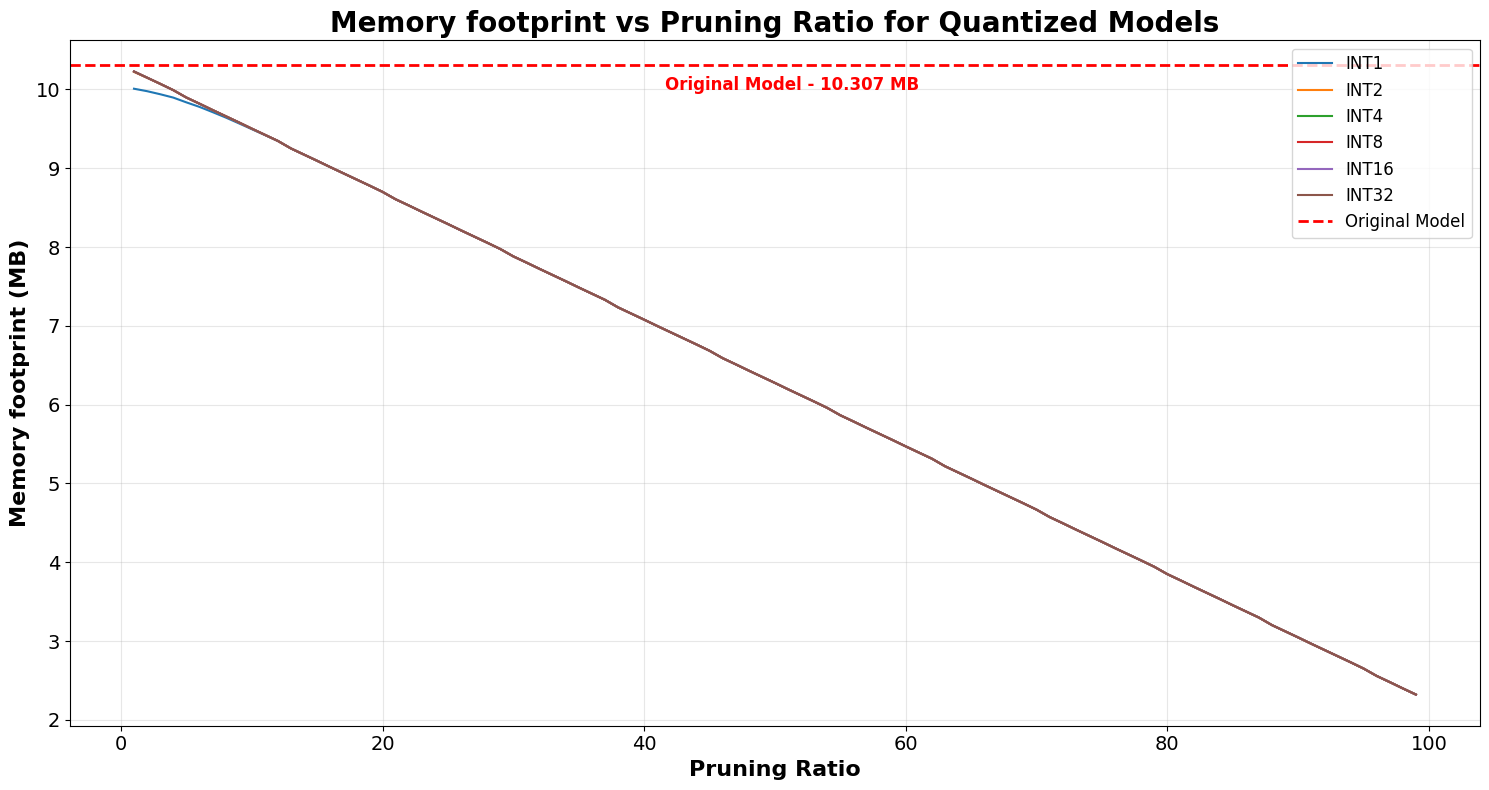

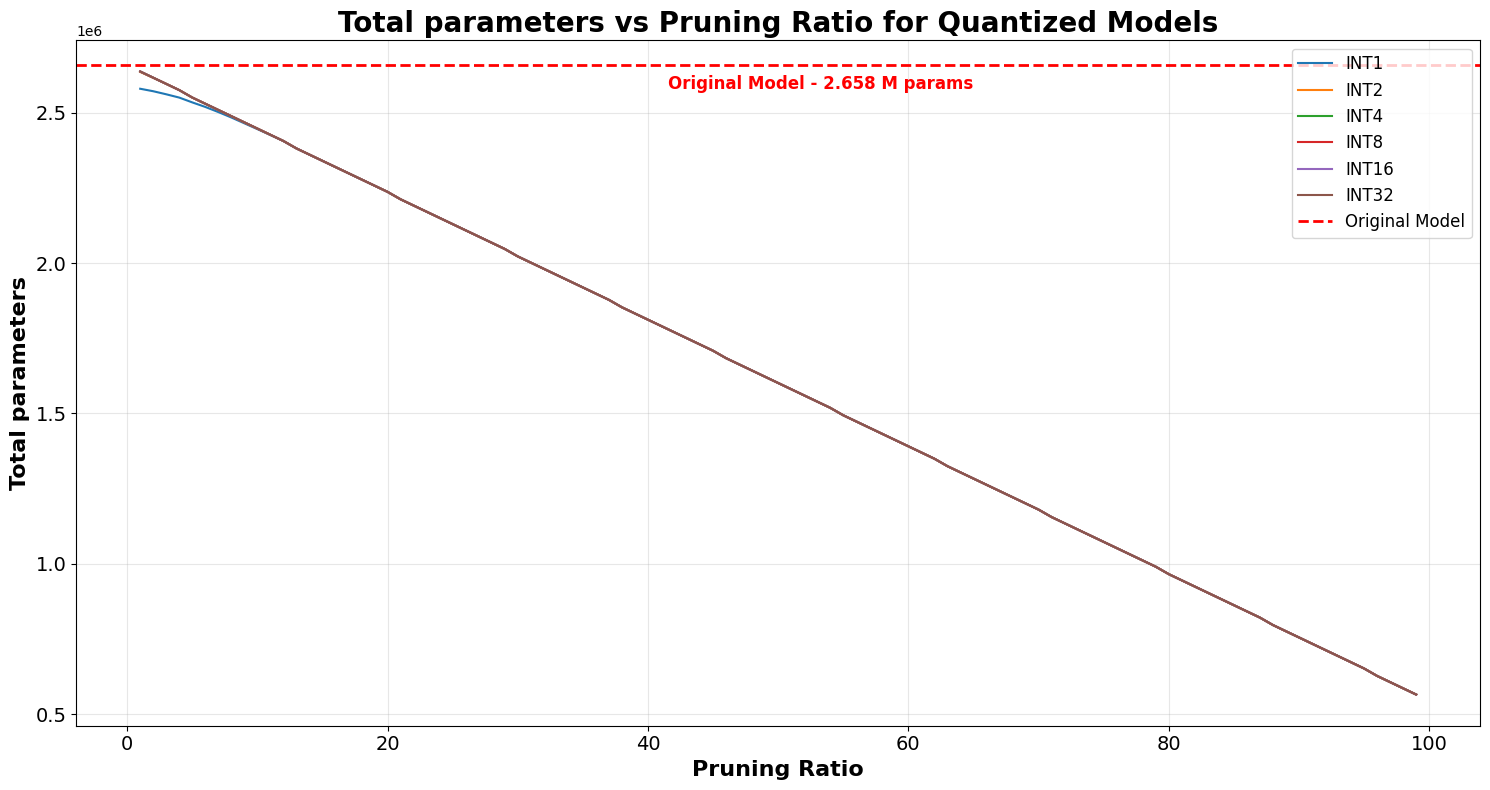

In [ ]:
### Plotting quantized + pruned results with original model baseline ###
bitwidths = [1, 2, 4, 8, 16, 32]
pruning_ratios = np.arange(1,100,1)
original_metrics = pd.read_pickle("original_model_metrics.pkl")
plotPruningNew("quantized_pruned_metrics", bitwidths, "Accuracy", "Accuracy vs Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "accuracy_vs_pruning_ratio_quantized.png")
plotPruningNew("quantized_pruned_metrics", bitwidths, "F1-score", "F1-score vs Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "f1_score_vs_pruning_ratio_quantized.png")
plotPruningNew("quantized_pruned_metrics", bitwidths, "Precision", "Precision vs Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "precision_vs_pruning_ratio_quantized.png")
plotPruningNew("quantized_pruned_metrics", bitwidths, "Est. Sample Inference time", "Avg. Sample Inference time vs Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "inference_time_vs_pruning_ratio_quantized.png")
plotPruningNew("quantized_pruned_metrics", bitwidths, "Memory footprint", "Memory footprint vs Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "memory_footprint_vs_pruning_ratio_quantized.png")
plotPruningNew("quantized_pruned_metrics", bitwidths, "Total parameters", "Total parameters vs Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "total_parameters_vs_pruning_ratio_quantized.png")

In [ ]:
# KD going first
kdFirstStuddent = knowledgeDistilation(modelForKDfirst,
                                       test_loader,
                                       train_loader,
                                       val_loader,
                                       device=device,
                                       lossTitle="Loss For the KD-Quantize-Prune pipeline",
                                       accTitle="Accuracy for the KD-Quantize-Prune Pipeline"
                                       )


C:\Users\mikep\AppData\Local\Temp\ipykernel_10496\3289879896.py:45: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



Teacher test loss: 0.5898 | Teacher test acc: 0.7879
###Student Training###
Early stopping at epoch 83 due to no improvement in loss for 3 consecutive epochs.
Epoch 083/100 | Train loss=0.2251 Train Accuracy=0.7621 | Validation loss=0.6617 Validation Accuracy=0.7702


In [ ]:

torch.save(kdFirstStuddent,"kdFirstStudentModel.pth")
kdFirstStudentModel = torch.load("kdFirstStudentModel.pth",map_location=device,weights_only=False)
pruning_ratios = np.arange(1,100,1)
bitwidths = [1, 2, 4, 8, 16, 32]
quant_prune_results_df = quant_then_prune(
    originalModel,
    bitwidths,
    pruning_ratios,
    val_loader,
    test_loader,
    device
)


Pruning ratio: 0.01
Rebuilt Transformer FFN dims per encoder layer: [482, 507, 507, 507, 507, 504, 507, 507, 507, 506, 505, 507, 492, 507, 493, 507, 491, 480, 505, 496, 450, 504, 472, 458, 472, 501, 479, 483, 487, 485, 490, 474]

Pruning ratio: 0.02
Rebuilt Transformer FFN dims per encoder layer: [482, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 492, 502, 493, 502, 491, 480, 502, 496, 450, 502, 472, 458, 472, 501, 479, 483, 487, 485, 490, 474]

Pruning ratio: 0.03
Rebuilt Transformer FFN dims per encoder layer: [482, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 492, 497, 493, 497, 491, 480, 497, 496, 450, 497, 472, 458, 472, 497, 479, 483, 487, 485, 490, 474]

Pruning ratio: 0.04
Rebuilt Transformer FFN dims per encoder layer: [482, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 492, 491, 480, 492, 492, 450, 492, 472, 458, 472, 492, 479, 483, 487, 485, 490, 474]

Pruning ratio: 0.05
Rebuilt Transformer FFN dims per encoder layer: [482, 486, 

In [ ]:
import winsound

winsound.PlaySound("Finished.wav", winsound.SND_FILENAME)

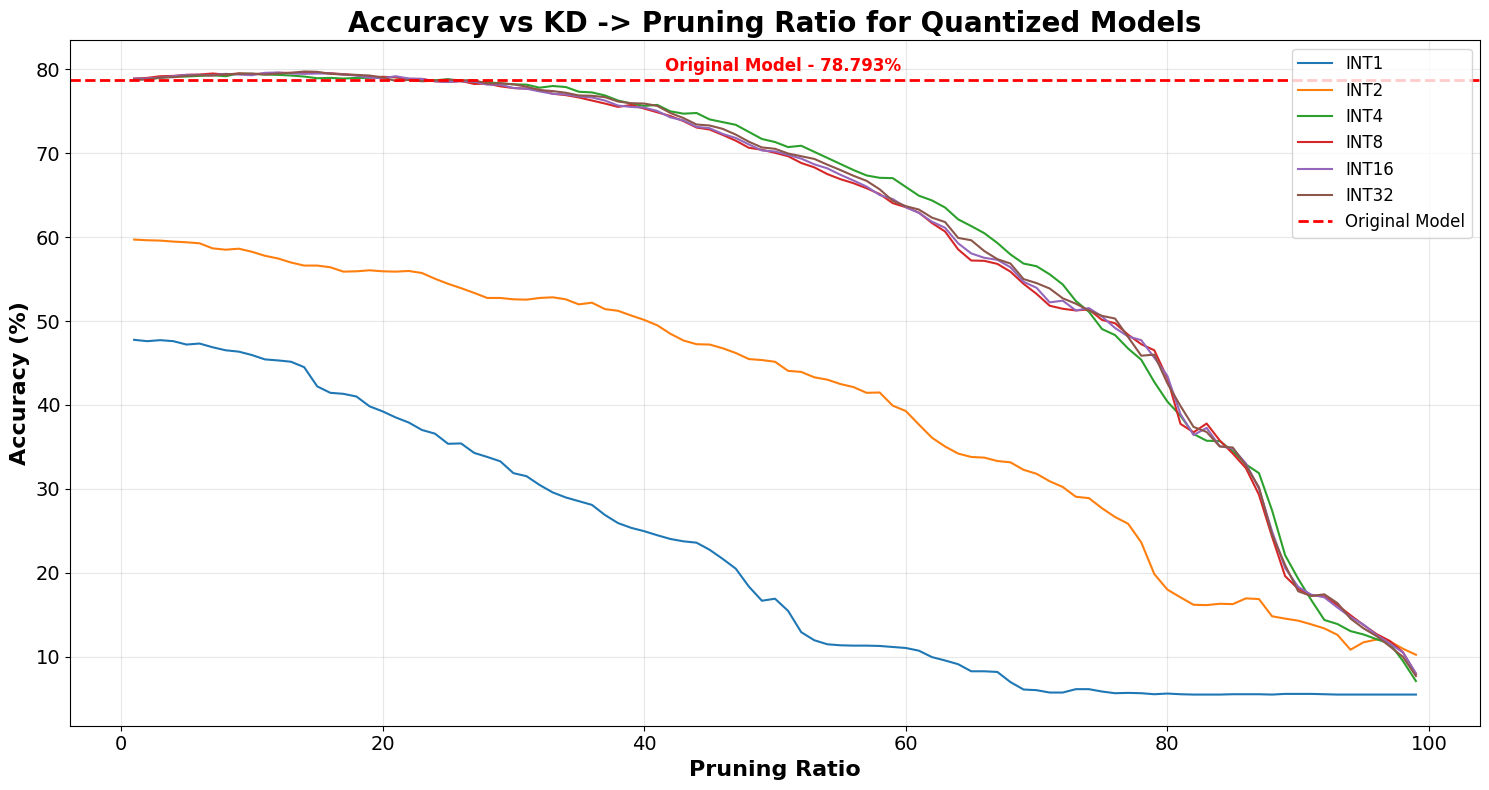

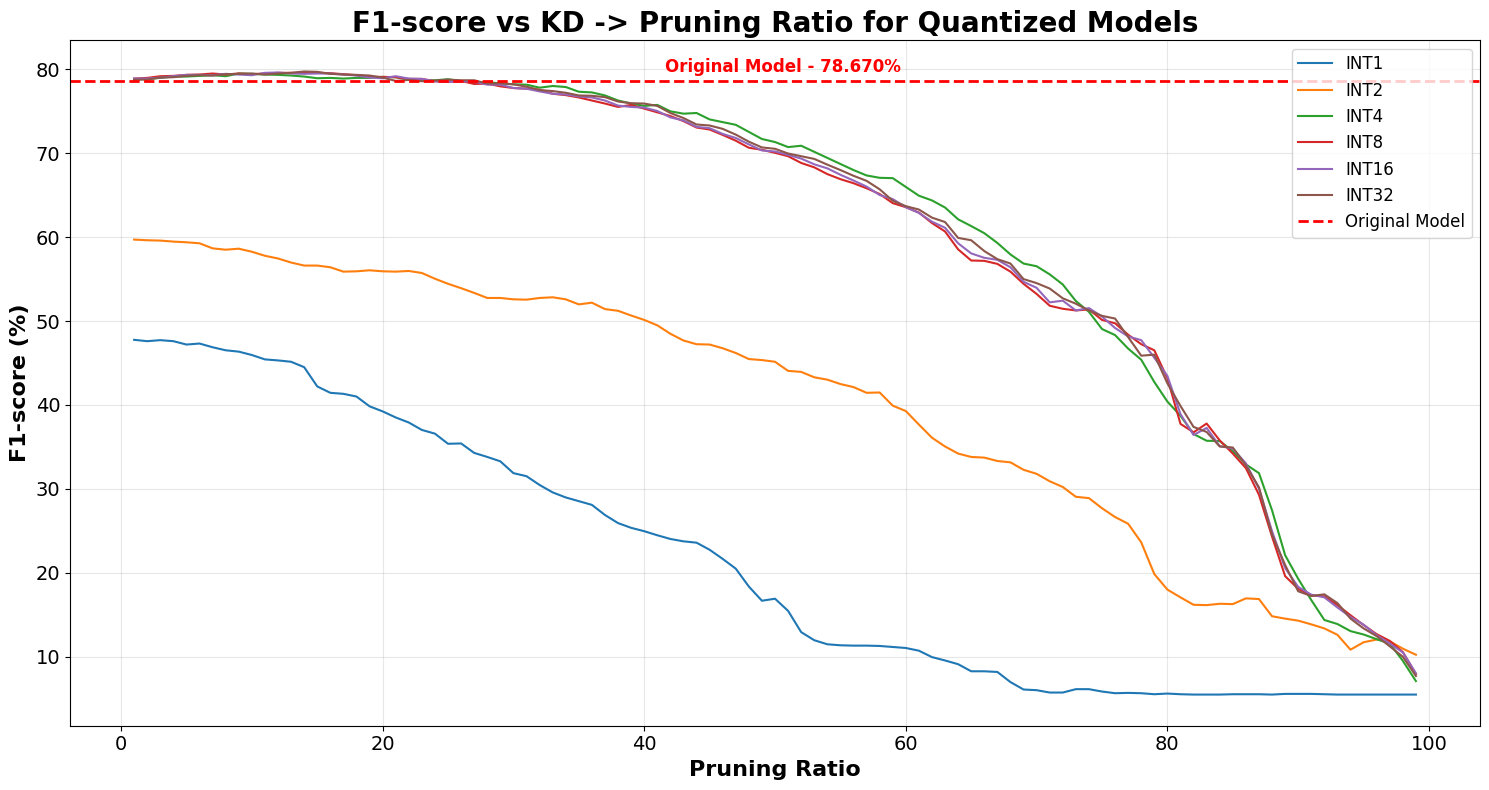

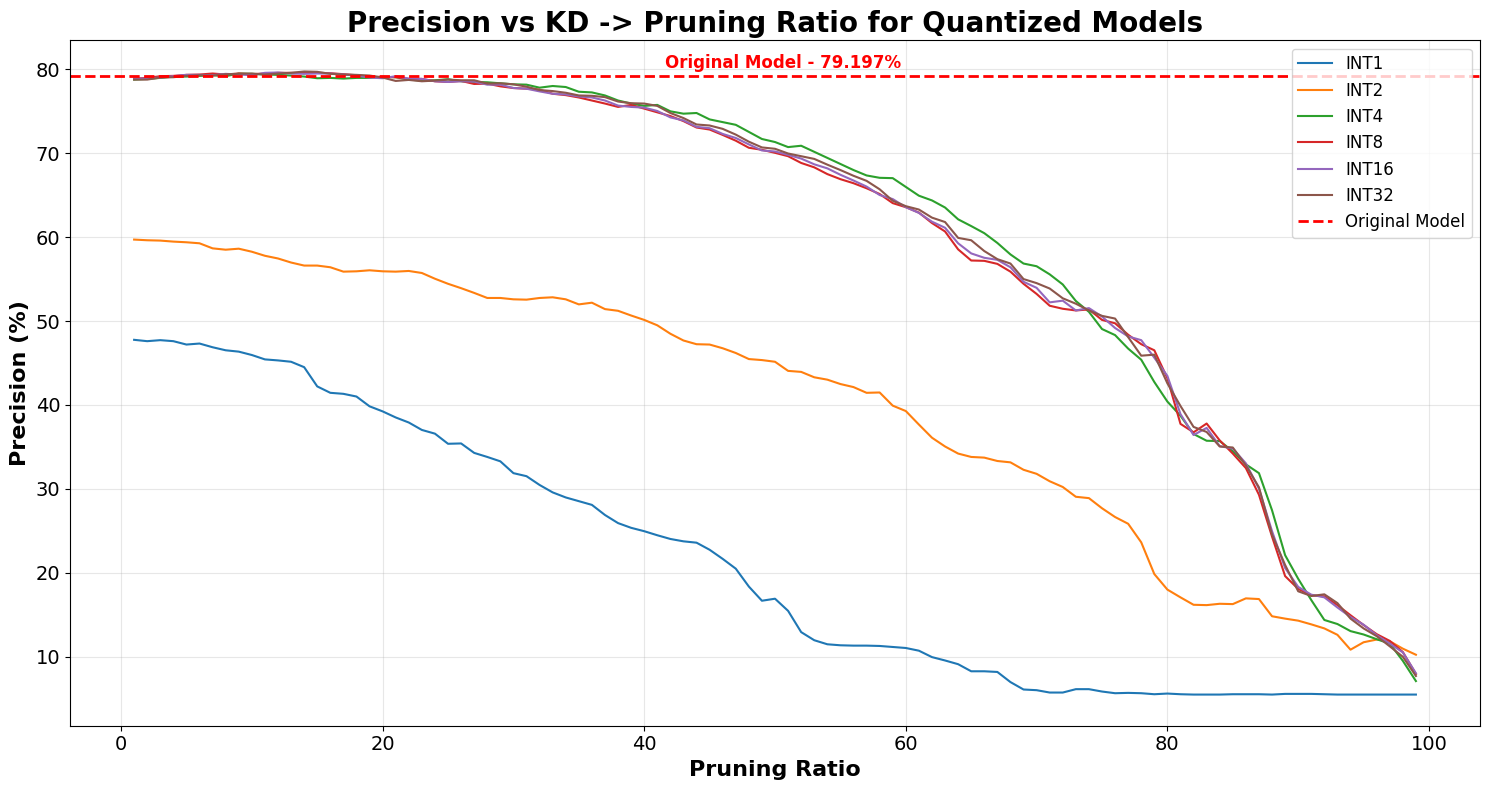

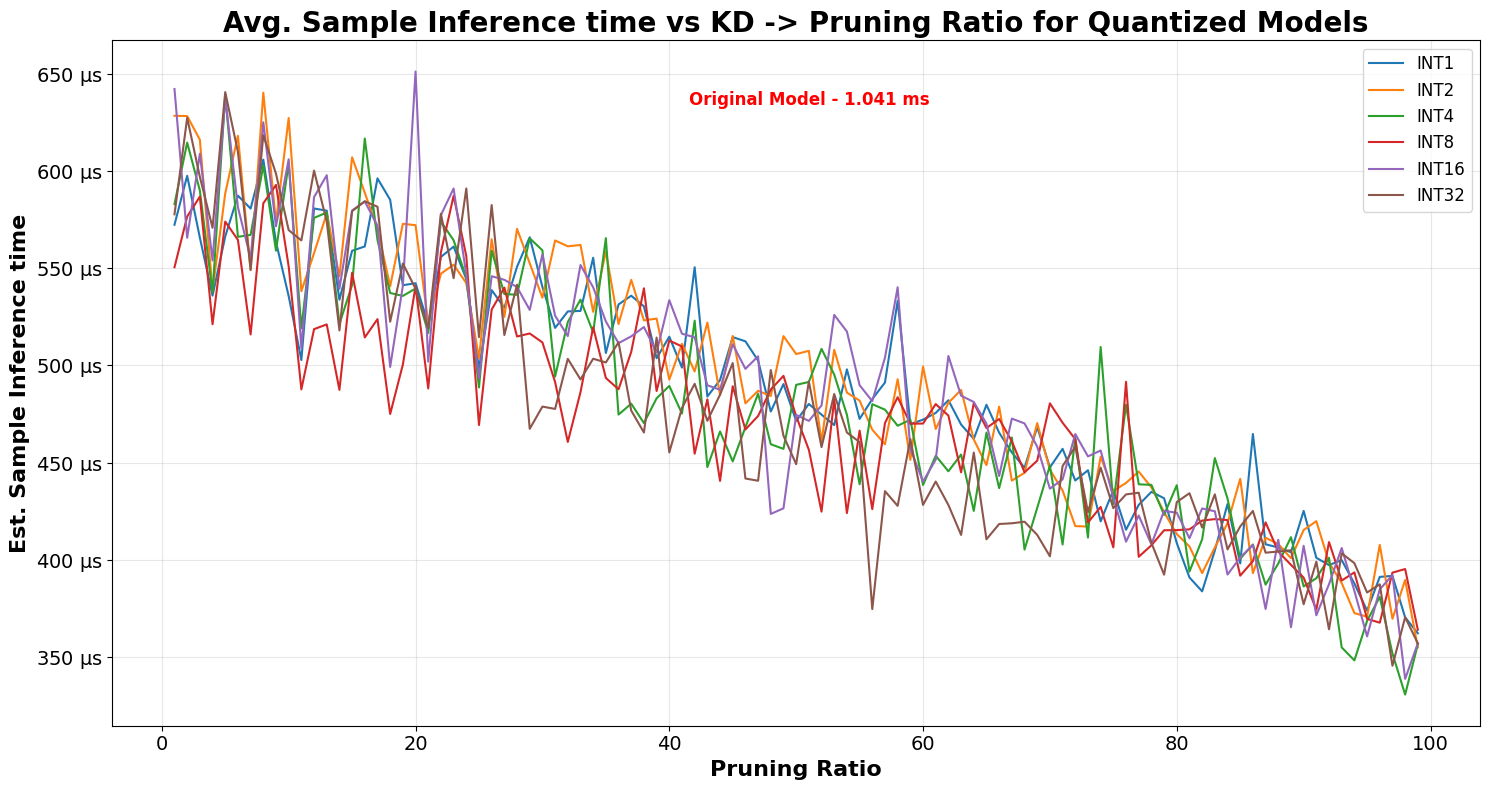

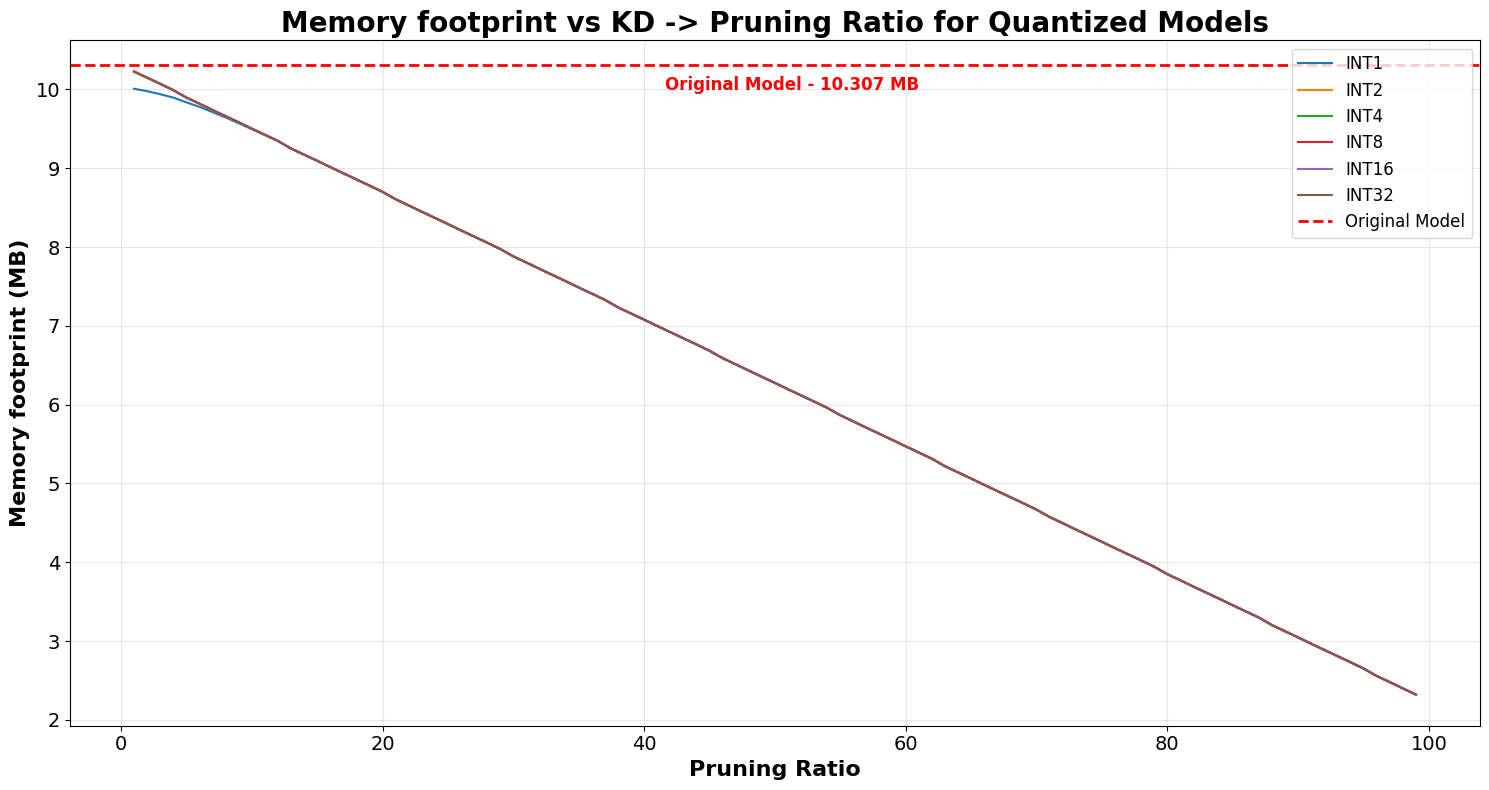

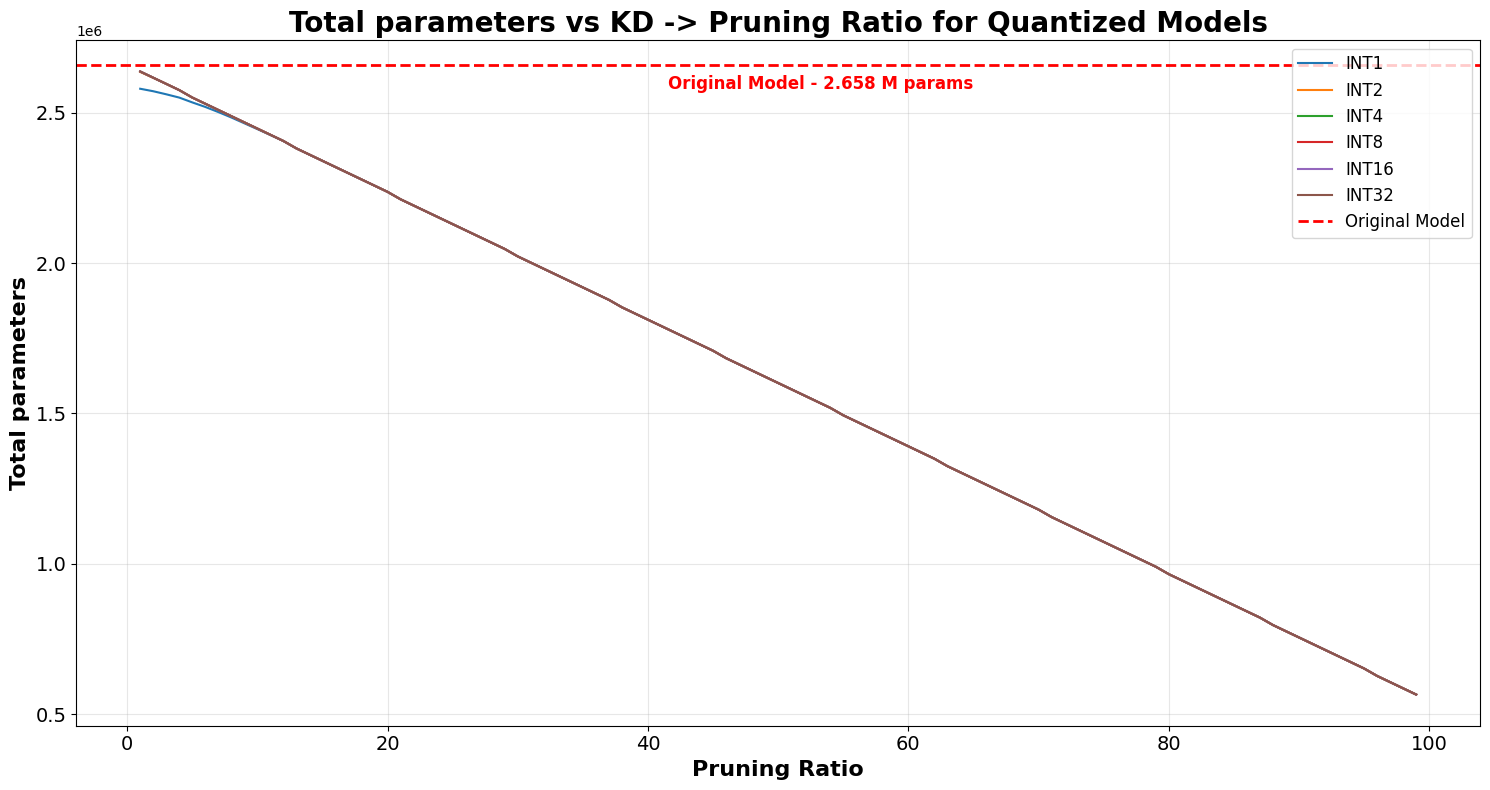

In [ ]:
bitwidths = [1, 2, 4, 8, 16, 32]
pruning_ratios = np.arange(1,100,1)
original_metrics = pd.read_pickle("original_model_metrics.pkl")
plotPruningNew("kd_quantized_pruned_metrics", bitwidths, "Accuracy", "Accuracy vs KD -> Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "accuracy_vs_kd_pruning_ratio_quantized.png")
plotPruningNew("kd_quantized_pruned_metrics", bitwidths, "F1-score", "F1-score vs KD -> Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "f1_score_vs_kd_pruning_ratio_quantized.png")
plotPruningNew("kd_quantized_pruned_metrics", bitwidths, "Precision", "Precision vs KD -> Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "precision_vs_kd_pruning_ratio_quantized.png")
plotPruningNew("kd_quantized_pruned_metrics", bitwidths, "Est. Sample Inference time", "Avg. Sample Inference time vs KD -> Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "inference_time_vs_kd_pruning_ratio_quantized.png")
plotPruningNew("kd_quantized_pruned_metrics", bitwidths, "Memory footprint", "Memory footprint vs KD -> Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "memory_footprint_vs_kd_pruning_ratio_quantized.png")
plotPruningNew("kd_quantized_pruned_metrics", bitwidths, "Total parameters", "Total parameters vs KD -> Pruning Ratio for Quantized Models", pruning_ratios, original_metrics, "total_parameters_vs_kd_pruning_ratio_quantized.png")

In [ ]:
# KD going last
def kdLast(
    model,
    bitwidths,
    device,
    train_loader,
    test_loader,
    val_loader,
    pruningRatio=25/100
):
    results = []

    for bitwidth in bitwidths:

        print("\n==============================")
        print(f"Quantize -> Prune -> KD | INT{bitwidth}")
        print("==============================")

        # --------------------------------------------------
        # 1. Quantize teacher
        # --------------------------------------------------
        teacher_quant_path = f"teacher_quant_int{bitwidth}.pth"

        save_quantized_model(
            model,
            teacher_quant_path,
            bitwidth
        )

        quantized_model = load_quantized_model(
            model,
            teacher_quant_path,
            device
        )

        # --------------------------------------------------
        # 2. Prune quantized teacher
        # --------------------------------------------------
        currentImportanceScore = compute_gradient_importance_scores(
            quantized_model,
            val_loader,
            device
        )

        pruned_model = structured_prune_ffn(
            quantized_model,
            amount=pruningRatio,
            importance_scores=currentImportanceScore
        )

        rebuilt_model = rebuild_model_pruned(
            pruned_model,
            threshold=0.0
        )

        # --------------------------------------------------
        # 3. KD using pruned + quantized teacher
        # --------------------------------------------------
        kdLastModel = knowledgeDistilation(
            rebuilt_model,
            test_loader,
            train_loader,
            val_loader,
            device=device,
            lossTitle=f"Loss for Quantize-Prune-KD INT{bitwidth}",
            accTitle=f"Accuracy for Quantize-Prune-KD INT{bitwidth}"
        )

        # --------------------------------------------------
        # 4. Save float32 KD student
        # --------------------------------------------------
        float_student_path = f"Quant_Prune_KD_model_int{bitwidth}_float32.pth"

        torch.save(
            kdLastModel,
            float_student_path
        )

        # --------------------------------------------------
        # 5. Quantize final KD student for stored-size comparison
        # --------------------------------------------------
        quant_student_path = f"Quant_Prune_KD_model_int{bitwidth}_quantized.pth"

        save_quantized_model(
            kdLastModel,
            quant_student_path,
            bitwidth
        )

        # --------------------------------------------------
        # 6. Evaluate float32 KD student
        # --------------------------------------------------
        evalDF = totalEvaulation(
            kdLastModel,
            test_loader,
            device,
            CM_title=f"Quantize -> Prune -> KD INT{bitwidth} Evaluation",
            CM_SaveName=f"quant_prune_kd_cm_int{bitwidth}",
            fileName=f"quant_prune_kd_metrics_int{bitwidth}",
            show_cm=False
        )

        # --------------------------------------------------
        # 7. Add correct metadata
        # --------------------------------------------------
        evalDF["Quantization Type"] = f"INT{bitwidth}"
        evalDF["Bit width"] = bitwidth
        evalDF["Float32 Student Size (MB)"] = get_model_size_mb(float_student_path)
        evalDF["Stored Model Size (MB)"] = get_model_size_mb(quant_student_path)
        evalDF["Teacher Quantized Size (MB)"] = get_model_size_mb(teacher_quant_path)

        results.append(evalDF)

    combined_results_df = pd.concat(
        results,
        ignore_index=True
    )

    combined_results_df.to_csv(
        "quantized_then_pruned_then_KD_results.csv",
        index=False
    )

    return combined_results_df

In [ ]:
combinedKDLast = kdLast(modelForKDlast,bitwidths,device,train_loader=train_loader,test_loader=test_loader,val_loader=val_loader)


Quantize -> Prune -> KD | INT1
Rebuilt Transformer FFN dims per encoder layer: [384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384]


C:\Users\mikep\AppData\Local\Temp\ipykernel_10496\3289879896.py:45: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



Teacher test loss: 2.1448 | Teacher test acc: 0.3537
###Student Training###
Early stopping at epoch 85 due to no improvement in loss for 3 consecutive epochs.
Epoch 085/100 | Train loss=0.0054 Train Accuracy=0.3015 | Validation loss=2.1743 Validation Accuracy=0.2946

Quantize -> Prune -> KD | INT2
Rebuilt Transformer FFN dims per encoder layer: [384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384]


C:\Users\mikep\AppData\Local\Temp\ipykernel_10496\3289879896.py:45: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



Teacher test loss: 1.1229 | Teacher test acc: 0.5445
###Student Training###
Epoch 100/100 | Train loss=0.1421 Train Accuracy=0.5097 | Validation loss=1.1892 Validation Accuracy=0.5050

Quantize -> Prune -> KD | INT4
Rebuilt Transformer FFN dims per encoder layer: [384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384]


C:\Users\mikep\AppData\Local\Temp\ipykernel_10496\3289879896.py:45: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



Teacher test loss: 0.5970 | Teacher test acc: 0.7883
###Student Training###
Epoch 100/100 | Train loss=0.1756 Train Accuracy=0.7627 | Validation loss=0.6689 Validation Accuracy=0.7686

Quantize -> Prune -> KD | INT8
Rebuilt Transformer FFN dims per encoder layer: [384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384]


C:\Users\mikep\AppData\Local\Temp\ipykernel_10496\3289879896.py:45: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



Teacher test loss: 0.6018 | Teacher test acc: 0.7851
###Student Training###


KeyboardInterrupt: 

In [ ]:
import winsound

winsound.PlaySound("Finished.wav", winsound.SND_FILENAME)

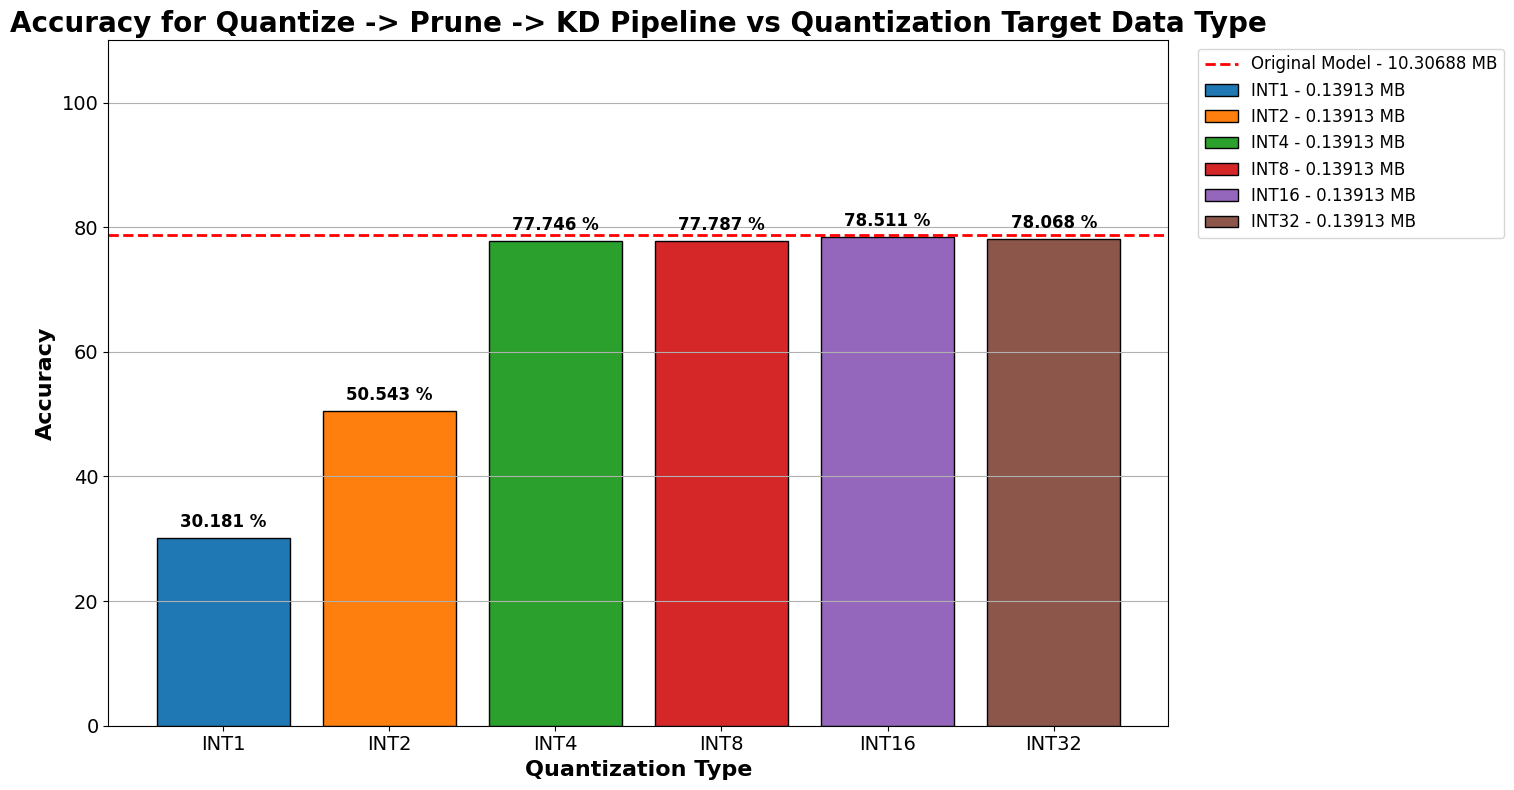

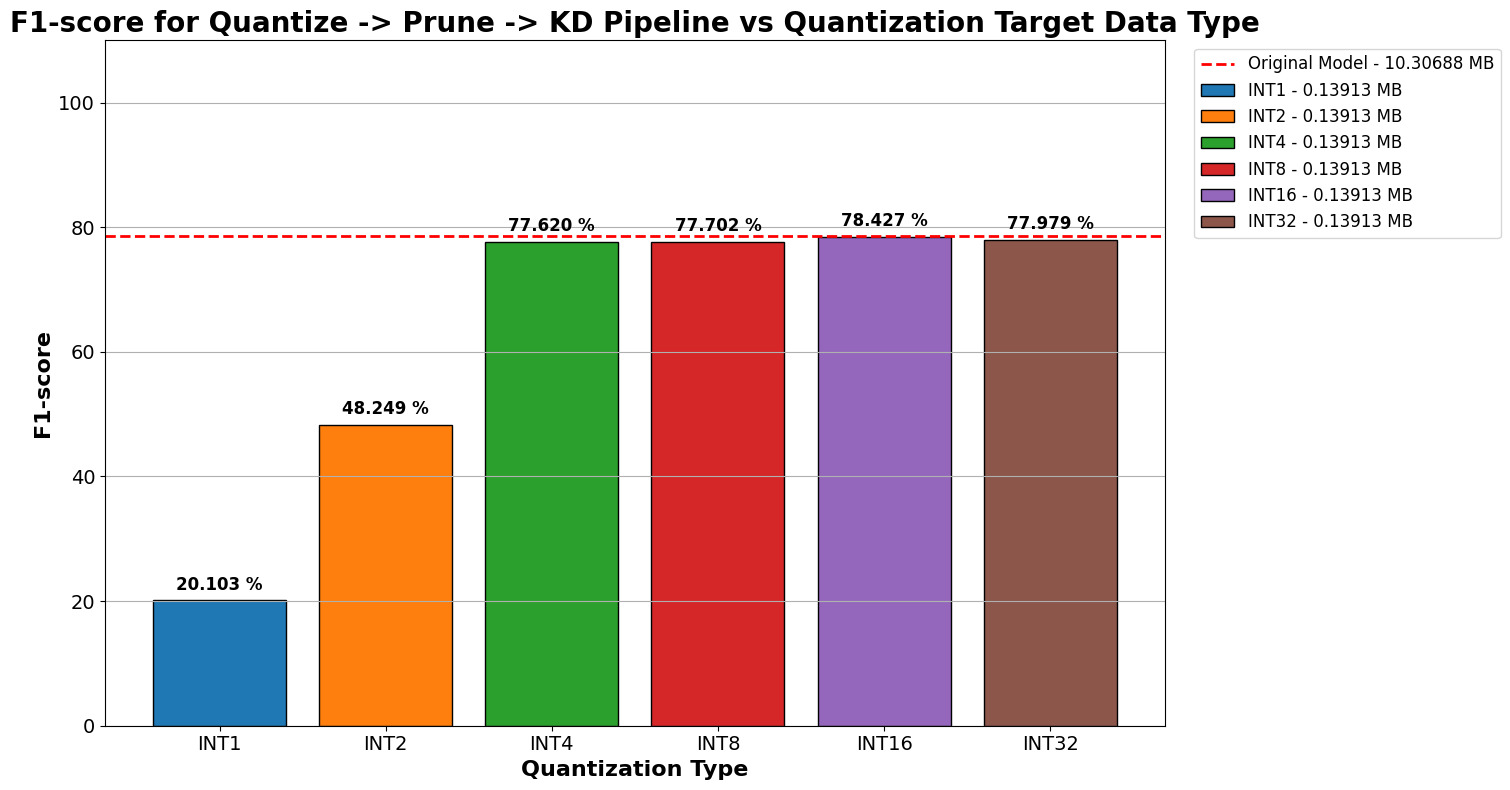

In [ ]:
## Plotting for KD Last Pipeline
#bitwidths = [1, 2, 4, 8, 16, 32]
kdLastMetrics_df = pd.read_csv("quantized_then_pruned_then_KD_results.csv")
original_metrics = pd.read_pickle("original_model_metrics.pkl")
"""def plot_quantization_metric_new(
    df,
    metric_name,
    ylabel,
    title,
    save_name,
    baseline_value=None,
    baseline_memory=None,
    memory_col="Stored Model Size (MB)"
):
"""
plot_quantization_metric_new_2(
    kdLastMetrics_df,
    metric_name = "Accuracy",
    ylabel = "Accuracy",
    title = "Accuracy for Quantize -> Prune -> KD Pipeline",
    save_name = "accuracy_quant_prune_kd.png",
    baseline_value = original_metrics["Accuracy"].iloc[0],
    baseline_memory = original_metrics["Memory footprint"].iloc[0]
)
plot_quantization_metric_new_2(
    kdLastMetrics_df,
    metric_name = "F1-score",
    ylabel = "F1-score",
    title = "F1-score for Quantize -> Prune -> KD Pipeline",
    save_name = "f1_score_quant_prune_kd.png",
    baseline_value = original_metrics["F1-score"].iloc[0],
    baseline_memory = original_metrics["Memory footprint"].iloc[0]
)



In [ ]:
import winsound

winsound.PlaySound("Finished.wav", winsound.SND_FILENAME)